# Stage 1 — Noiseless lensed mock and recovery check

This stage generates intrinsic and noiseless lensed mock cubes using the truth lens. As a final sanity check, it fits each lensed cube with the parameters selected in `mock_stage1.toml`.

1. generate the physical mass cases and intrinsic source cubes;
2. map them through the lens and inspect the lensed cubes;
3. fit the noiseless lensed cubes without a PSF or noise.

Mass, source, and lens parameters can each be fixed to truth or made free through the TOML configuration. Stage 2 adds a PSF and noise.

In [3]:
import hashlib
import json
import tomllib
from itertools import product
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from astropy.table import Table
from astropy.constants import c as const_c

from glint import lensing
from glint.context import ImageContext
from glint.cosmology import critical_density, kpc_per_arcsec
from glint.forward import forward_model_3D_mass_intrinsic, mass_rotation_curve
from glint.inference import run_least_squares, run_parallel_fits
from glint.mass_model import r200_kpc_from_m200
from glint.plotstyle import set_my_plot_style

set_my_plot_style()

%matplotlib inline

print("Place mock_truth.toml and mock_stage1.toml in the same directory as this notebook.")
EXAMPLE_DIR = Path.cwd().resolve()

Place mock_truth.toml and mock_stage1.toml in the same directory as this notebook.


## Configuration

`mock_truth.toml` contains every parameter used to generate the mock data. It is the single source of truth shared by the later stages. `mock_stage1.toml` is read only for the optional noiseless recovery check at the end.

The parameters are grouped into:

- **mass parameters**: disk, bulge, and NFW halo;
- **source parameters**: position, flux profile, orientation, and velocity dispersion;
- **lens parameters**: fixed SIE + external shear/convergence.

Redshift-dependent conversion factors are computed once here and then passed explicitly to the mass model.

In [4]:
with (EXAMPLE_DIR / 'mock_truth.toml').open('rb') as handle:
    TRUTH_CONFIG = tomllib.load(handle)
SOURCE_REDSHIFT = float(TRUTH_CONFIG['target']['redshift'])
KPC_PER_ARCSEC = kpc_per_arcsec(SOURCE_REDSHIFT)
RHO_CRITICAL_MSUN_KPC3 = critical_density(SOURCE_REDSHIFT)

MASS_PARAMETER_NAMES = (
    'log10_m_baryon',
    'disk_scale_radius_kpc',
    'log10_m200',
    'bulge_to_total',
    'bulge_effective_radius_kpc',
)
SOURCE_PARAMETER_NAMES = (
    'source_x_arcsec',
    'source_y_arcsec',
    'flux_normalization',
    'inclination_deg',
    'position_angle_deg',
    'surface_brightness_scale_arcsec',
    'velocity_dispersion_center_kms',
    'velocity_dispersion_scale_arcsec',
    'systemic_velocity_kms',
)
LENS_PARAMETER_NAMES = (
    'lens_x_arcsec',
    'lens_y_arcsec',
    'einstein_radius_arcsec',
    'lens_axis_ratio',
    'lens_position_angle_deg',
    'log10_external_shear',
    'external_shear_position_angle_deg',
    'external_convergence',
)
ALL_PARAMETER_NAMES = MASS_PARAMETER_NAMES + SOURCE_PARAMETER_NAMES + LENS_PARAMETER_NAMES
print(f'z = {SOURCE_REDSHIFT:.3f}')
print(f'kpc/arcsec = {KPC_PER_ARCSEC:.4f}')
print(f'rho_critical = {RHO_CRITICAL_MSUN_KPC3:.4e} Msun/kpc^3')

z = 6.024
kpc/arcsec = 5.6972
rho_critical = 1.4262e+04 Msun/kpc^3


## Independent source- and image-plane grids

The intrinsic source and lensed image are evaluated on separate grids:

- the **source-plane grid** resolves the galaxy before lensing;
- the **image-plane grid** covers the larger lensed field supplied to later observing simulations;
- the **radial grid** is a one-dimensional grid used to tabulate the rotation curve, surface brightness, and velocity dispersion.

The source grid is three times finer than the image grid for numerical interpolation. This is an oversampling choice; a total magnification near nine does not imply an isotropic factor-of-three physical resolution gain everywhere. The local lens Jacobian determines the directional resolution.

In [5]:
source_grid_cfg = TRUTH_CONFIG['grid']['source']
image_grid_cfg = TRUTH_CONFIG['grid']['image']
spectral_cfg = TRUTH_CONFIG['spectral']
radial_cfg = TRUTH_CONFIG['radial_profile']

XX_SOURCE_ARCSEC, YY_SOURCE_ARCSEC = lensing.make_grid_arcsec(
    nx=source_grid_cfg['grid_size'],
    ny=source_grid_cfg['grid_size'],
    pixscale_arcsec=source_grid_cfg['pixel_size_arcsec'],
    x0_arcsec=source_grid_cfg['x_center_arcsec'],
    y0_arcsec=source_grid_cfg['y_center_arcsec'],
)
XX_IMAGE_ARCSEC, YY_IMAGE_ARCSEC = lensing.make_grid_arcsec(
    nx=image_grid_cfg['grid_size'],
    ny=image_grid_cfg['grid_size'],
    pixscale_arcsec=image_grid_cfg['pixel_size_arcsec'],
    x0_arcsec=image_grid_cfg['x_center_arcsec'],
    y0_arcsec=image_grid_cfg['y_center_arcsec'],
)

# Convert the requested physical radius to an arcsec grid and round the endpoint upward.
RADIUS_MAX_KPC = float(radial_cfg['radius_max_kpc'])
RADIAL_STEP_ARCSEC = float(radial_cfg['radial_step_arcsec'])
if RADIUS_MAX_KPC <= 0 or RADIAL_STEP_ARCSEC <= 0:
    raise ValueError('radius_max_kpc and radial_step_arcsec must be positive')
RADIAL_INTERVALS = int(np.ceil((RADIUS_MAX_KPC / KPC_PER_ARCSEC) / RADIAL_STEP_ARCSEC))
RADIUS_ARCSEC = np.arange(RADIAL_INTERVALS + 1) * RADIAL_STEP_ARCSEC
RADIUS_MAX_ARCSEC = RADIUS_ARCSEC[-1]
RADIUS_KPC = RADIUS_ARCSEC * KPC_PER_ARCSEC
VELOCITY_CHANNELS_KMS = np.arange(
    spectral_cfg['velocity_min_kms'],
    spectral_cfg['velocity_max_kms'] + 0.5 * spectral_cfg['channel_width_kms'],
    spectral_cfg['channel_width_kms'],
)

source_truth = TRUTH_CONFIG['truth']['source']
lens_truth = TRUTH_CONFIG['truth']['lens']

print('source cube:', (VELOCITY_CHANNELS_KMS.size, *XX_SOURCE_ARCSEC.shape),
      f"at {source_grid_cfg['pixel_size_arcsec']:.5f} arcsec/pixel")
print('image cube: ', (VELOCITY_CHANNELS_KMS.size, *XX_IMAGE_ARCSEC.shape),
      f"at {image_grid_cfg['pixel_size_arcsec']:.3f} arcsec/pixel")
print(f'radial grid: 0--{RADIUS_MAX_ARCSEC:.3f} arcsec '
      f'({RADIUS_KPC[-1]:.3f} kpc), step={RADIAL_STEP_ARCSEC:.3f} arcsec')

source cube: (33, 100, 100) at 0.01000 arcsec/pixel
image cube:  (33, 200, 200) at 0.030 arcsec/pixel
radial grid: 0--0.880 arcsec (5.014 kpc), step=0.010 arcsec


## Physical mass cases

Each case changes the bulge-to-total baryonic mass ratio and bulge effective radius while keeping the total baryonic mass, disk scale radius, and halo mass fixed. The optional `bt00` case contains no bulge; its bulge radius is therefore physically undefined and stored as `NaN` internally.

`truth_parameters()` combines the case-dependent mass parameters with the common source and lens truth values. This gives every forward-model call the same flat parameter dictionary.

The case-name formatter remains local because it is an examples-only output convention, not part of the scientific `glint` API.

In [6]:
mass_truth = TRUTH_CONFIG['truth']['mass']

def case_name(bulge_to_total, bulge_effective_radius_kpc):
    return f'bt{round(100 * bulge_to_total):02d}_re{round(10 * bulge_effective_radius_kpc):02d}'

def make_cases():
    # These quantities are identical in every bulge experiment.
    common = {
        'log10_m_baryon': np.log10(mass_truth['total_baryonic_mass_msun']),
        'disk_scale_radius_kpc': float(mass_truth['disk_scale_radius_kpc']),
        'log10_m200': np.log10(mass_truth['halo_mass_200_msun']),
    }
    cases = [
        {
            'name': case_name(bt, re_kpc),
            **common,
            'bulge_to_total': float(bt),
            'bulge_effective_radius_kpc': float(re_kpc),
        }
        for bt, re_kpc in product(
            mass_truth['bulge_to_total_values'],
            mass_truth['bulge_effective_radii_kpc'],
        )
    ]
    # For B/T=0 the bulge radius never enters the forward model.
    if mass_truth.get('include_no_bulge_case', False):
        cases.append({
            'name': 'bt00',
            **common,
            'bulge_to_total': 0.0,
            'bulge_effective_radius_kpc': np.nan,
        })
    return tuple(cases)

CASES = make_cases()

def truth_parameters(case):
    return {
        **{name: float(case[name]) for name in MASS_PARAMETER_NAMES},
        **{name: float(source_truth[name]) for name in SOURCE_PARAMETER_NAMES},
        **{name: float(lens_truth[name]) for name in LENS_PARAMETER_NAMES},
    }

Table(
    rows=[(case['name'], *(case[name] for name in MASS_PARAMETER_NAMES)) for case in CASES],
    names=('case', *MASS_PARAMETER_NAMES),
)

case,log10_m_baryon,disk_scale_radius_kpc,log10_m200,bulge_to_total,bulge_effective_radius_kpc
str9,float64,float64,float64,float64,float64
bt10_re03,11.0,1.0,11.477121254719663,0.1,0.3
bt10_re06,11.0,1.0,11.477121254719663,0.1,0.6
bt25_re03,11.0,1.0,11.477121254719663,0.25,0.3
bt25_re06,11.0,1.0,11.477121254719663,0.25,0.6
bt50_re03,11.0,1.0,11.477121254719663,0.5,0.3
bt50_re06,11.0,1.0,11.477121254719663,0.5,0.6
bt00,11.0,1.0,11.477121254719663,0.0,nan


## Physical source-cube model

The empirical Courteau rotation curve is not used. Circular-speed contributions are calculated directly from the exponential disk, Hernquist bulge, and NFW halo and are added in quadrature by `mass_rotation_curve`.

The intrinsic cube is then constructed from:

1. the physical rotation curve;
2. an exponential radial surface-brightness profile;
3. an exponential radial velocity-dispersion profile;
4. the source position, inclination, position angle, and systemic velocity.

All source parameters are read from the shared truth file; later stages can choose which of them are free without changing the cube generator.

In [7]:
HALO_CONCENTRATION_200 = float(mass_truth['halo_concentration_200'])

def physical_keywords(parameters):
    # B/T partitions the fixed baryonic mass between bulge and disk.
    baryonic_mass = 10.0 ** parameters['log10_m_baryon']
    bulge_mass = parameters['bulge_to_total'] * baryonic_mass
    halo_mass = 10.0 ** parameters['log10_m200']
    return {
        'disk_mass_msun': baryonic_mass - bulge_mass,
        'disk_scale_radius_kpc': parameters['disk_scale_radius_kpc'],
        'bulge_mass_msun': bulge_mass,
        'bulge_effective_radius_kpc': parameters['bulge_effective_radius_kpc'],
        'halo_mass_200_msun': halo_mass,
        'halo_radius_200_kpc': r200_kpc_from_m200(halo_mass, RHO_CRITICAL_MSUN_KPC3),
        'halo_concentration_200': HALO_CONCENTRATION_200,
    }

def rotation_curve(parameters):
    return mass_rotation_curve(radius_kpc=RADIUS_KPC, **physical_keywords(parameters))

def intrinsic_cube(parameters):
    # Tabulate the radial tracer profiles on the same grid as the rotation curve.
    surface_brightness = (
        parameters['flux_normalization']
        * np.exp(-RADIUS_ARCSEC / parameters['surface_brightness_scale_arcsec'])
    )
    velocity_dispersion = (
        parameters['velocity_dispersion_center_kms']
        * np.exp(-RADIUS_ARCSEC / parameters['velocity_dispersion_scale_arcsec'])
    )
    return forward_model_3D_mass_intrinsic(
        xx_arcsec=XX_SOURCE_ARCSEC,
        yy_arcsec=YY_SOURCE_ARCSEC,
        radius_arcsec=RADIUS_ARCSEC,
        kpc_per_arcsec=KPC_PER_ARCSEC,
        velocity_channels_kms=VELOCITY_CHANNELS_KMS,
        surface_brightness_profile=surface_brightness,
        velocity_dispersion_profile_kms=velocity_dispersion,
        inclination_deg=parameters['inclination_deg'],
        position_angle_deg=parameters['position_angle_deg'],
        x_center_arcsec=parameters['source_x_arcsec'],
        y_center_arcsec=parameters['source_y_arcsec'],
        systemic_velocity_kms=parameters['systemic_velocity_kms'],
        spectral_resolution_sigma_kms=spectral_cfg['spectral_resolution_sigma_kms'],
        radius_max_arcsec=RADIUS_MAX_ARCSEC,
        **physical_keywords(parameters),
    )

## Fixed lens mapping

Stage 1 uses the lens parameters in `mock_truth.toml` without fitting them. The SIE + external shear/convergence deflection is evaluated at every image-plane pixel, and the corresponding source coordinate is

$$\boldsymbol{\beta}=\boldsymbol{\theta}-\boldsymbol{\alpha}(\boldsymbol{\theta}).$$

The intrinsic source cube is interpolated at these coordinates. Surface brightness is conserved by lensing; multiplication by the image-pixel area converts the mapped values from Jy arcsec$^{-2}$ to Jy pixel$^{-1}$.

Critical lines live in the image plane, whereas their mapped caustics live in the source plane. The analytic SIE + external-shear Jacobian is used to calculate both.

In [8]:
mock_numerics = TRUTH_CONFIG['mock_numerics']

def lens_keywords(parameters):
    return {
        'x0': parameters['lens_x_arcsec'],
        'y0': parameters['lens_y_arcsec'],
        'b': parameters['einstein_radius_arcsec'],
        'q': parameters['lens_axis_ratio'],
        'pa': np.deg2rad(parameters['lens_position_angle_deg']),
        'log_gamma': parameters['log10_external_shear'],
        'pa_gamma': np.deg2rad(parameters['external_shear_position_angle_deg']),
        'kappa': parameters['external_convergence'],
    }

REFERENCE_PARAMETERS = truth_parameters(CASES[0])
LENS_PARAMETERS = lens_keywords(REFERENCE_PARAMETERS)
LENS_CONTEXT = ImageContext(
    xx_img=XX_IMAGE_ARCSEC,
    yy_img=YY_IMAGE_ARCSEC,
    xx_src=XX_SOURCE_ARCSEC,
    yy_src=YY_SOURCE_ARCSEC,
    pixsize_img=image_grid_cfg['pixel_size_arcsec'],
    pixsize_src=source_grid_cfg['pixel_size_arcsec'],
    x0_src=source_grid_cfg['x_center_arcsec'],
    y0_src=source_grid_cfg['y_center_arcsec'],
    x0_l=lens_truth['lens_x_arcsec'],
    y0_l=lens_truth['lens_y_arcsec'],
)
LENS_GEOMETRY = lensing.compute_critical_lines_and_caustics(
    ctx=LENS_CONTEXT,
    deflector=lensing.deflection_SIE_plus_ES,
    deflector_jacobian=lensing.deflection_jacobian_SIE_plus_ES,
    lens_params=LENS_PARAMETERS,
    min_points=10,
    min_length=0.05,
)

def lensed_cube(source_cube, parameters):
    # Ray trace image pixels back to beta = theta - alpha(theta).
    alpha_x, alpha_y = lensing.deflection_SIE_plus_ES(
        XX_IMAGE_ARCSEC, YY_IMAGE_ARCSEC, **lens_keywords(parameters),
    )
    lensed_surface_brightness = lensing.map_source_to_image_cube(
        beta_x_arcsec=XX_IMAGE_ARCSEC - alpha_x,
        beta_y_arcsec=YY_IMAGE_ARCSEC - alpha_y,
        source_cube=source_cube,
        src_pixscale_arcsec=source_grid_cfg['pixel_size_arcsec'],
        order=int(mock_numerics['lensing_interpolation_order']),
        x0_src_arcsec=source_grid_cfg['x_center_arcsec'],
        y0_src_arcsec=source_grid_cfg['y_center_arcsec'],
    )
    # Lensing conserves surface brightness; pixel area converts Jy/arcsec^2 to Jy/pixel.
    return lensed_surface_brightness * image_grid_cfg['pixel_size_arcsec']**2

print('critical-line segments:', len(LENS_GEOMETRY['critical_lines']))
print('caustic segments:', len(LENS_GEOMETRY['caustics']))

critical-line segments: 1
caustic segments: 1


## Intrinsic and lensed mock cubes

For every mass case, this section creates:

- `INTRINSIC_CUBES`: source-plane surface brightness in Jy arcsec$^{-2}$;
- `LENSED_CUBES`: image-plane flux in Jy pixel$^{-1}$.

No PSF and no noise are applied. Consequently Stage 1 has no meaningful S/N value; peak S/N is introduced in Stage 2.

The tabulated magnification is the ratio of total lensed flux to total intrinsic flux. The intrinsic sum must be multiplied by the source-pixel area, while the lensed cube already contains flux per image pixel.

In [9]:
TRUTH_PARAMETERS = {case['name']: truth_parameters(case) for case in CASES}
INTRINSIC_CUBES = {
    case['name']: intrinsic_cube(TRUTH_PARAMETERS[case['name']])
    for case in CASES
}
LENSED_CUBES = {
    case['name']: lensed_cube(INTRINSIC_CUBES[case['name']], TRUTH_PARAMETERS[case['name']])
    for case in CASES
}

# Compare integrated fluxes; the source cube still needs its pixel-area factor.
magnification_rows = []
for case in CASES:
    source_flux = (
        INTRINSIC_CUBES[case['name']].sum()
        * source_grid_cfg['pixel_size_arcsec']**2
    )
    lensed_flux = LENSED_CUBES[case['name']].sum()
    magnification_rows.append((case['name'], source_flux, lensed_flux, lensed_flux / source_flux))

MAGNIFICATION_TABLE = Table(
    rows=magnification_rows,
    names=('case', 'intrinsic_flux', 'lensed_flux', 'flux_magnification'),
)
for name in MAGNIFICATION_TABLE.colnames[1:]:
    MAGNIFICATION_TABLE[name].format = '.5g'
MAGNIFICATION_TABLE

case,intrinsic_flux,lensed_flux,flux_magnification
str9,float32,float32,float32
bt10_re03,0.17039,1.599,9.3844
bt10_re06,0.17039,1.599,9.3844
bt25_re03,0.17038,1.599,9.3844
bt25_re06,0.17039,1.599,9.3844
bt50_re03,0.16935,1.5897,9.3872
bt50_re06,0.17038,1.5989,9.3844
bt00,0.17039,1.599,9.3844


## Save reusable mock cubes

Each case is written once so that later stages do not regenerate the galaxy or lens mapping:

- `intrinsic_source_cube.fits`: source-plane cube for inspection;
- `lensed_sky_cube.fits`: celestial-WCS cube used by Stage 2 and CASA `simobserve`;
- `mock_manifest.json`: relative file paths, truth parameters, grids, spectral setup, and SHA-256 hashes.

The hashes allow downstream notebooks to detect whether their input mock data changed. CASA needs a sky-coordinate WCS, so only the lensed FITS uses RA/Dec axes.

In [10]:
C_KMS = const_c.to('km/s').value


def frequencies_from_radio_velocity(velocity_kms, reference_frequency_hz):
    return reference_frequency_hz * (1.0 - np.asarray(velocity_kms) / C_KMS)


def write_intrinsic_source_fits(path, cube):
    """Save the intrinsic source-plane surface-brightness cube."""
    frequencies_hz = frequencies_from_radio_velocity(
        VELOCITY_CHANNELS_KMS, REFERENCE_FREQUENCY_HZ,
    )
    ny, nx = cube.shape[-2:]
    header = fits.Header()
    header["BUNIT"] = "Jy/arcsec2"
    header["BTYPE"] = "Intensity"
    header["CTYPE1"] = "XOFFSET"
    header["CTYPE2"] = "YOFFSET"
    header["CTYPE3"] = "FREQ"
    header["CUNIT1"] = "arcsec"
    header["CUNIT2"] = "arcsec"
    header["CUNIT3"] = "Hz"
    # FITS uses one-based pixel coordinates; this is the geometric array center.
    header["CRPIX1"] = (nx + 1.0) / 2.0
    header["CRPIX2"] = (ny + 1.0) / 2.0
    header["CRPIX3"] = 1.0
    header["CRVAL1"] = source_grid_cfg["x_center_arcsec"]
    header["CRVAL2"] = source_grid_cfg["y_center_arcsec"]
    header["CRVAL3"] = frequencies_hz[0]
    header["CDELT1"] = source_grid_cfg["pixel_size_arcsec"]
    header["CDELT2"] = source_grid_cfg["pixel_size_arcsec"]
    header["CDELT3"] = np.median(np.diff(frequencies_hz))
    fits.writeto(path, np.asarray(cube, dtype=np.float32), header, overwrite=True)


def write_lensed_sky_fits(path, cube):
    """Save the image-plane lensed cube with celestial WCS for CASA."""
    frequencies_hz = frequencies_from_radio_velocity(
        VELOCITY_CHANNELS_KMS, REFERENCE_FREQUENCY_HZ,
    )
    ny, nx = cube.shape[-2:]
    target = TRUTH_CONFIG["target"]
    header = fits.Header()
    header["BUNIT"] = "Jy/pixel"
    header["BTYPE"] = "Intensity"
    header["RADESYS"] = "ICRS"
    header["SPECSYS"] = "LSRK"
    header["RESTFRQ"] = REFERENCE_FREQUENCY_HZ
    header["CTYPE1"] = "RA---TAN"
    header["CTYPE2"] = "DEC--TAN"
    header["CTYPE3"] = "FREQ"
    header["CUNIT1"] = "deg"
    header["CUNIT2"] = "deg"
    header["CUNIT3"] = "Hz"
    # FITS uses one-based pixel coordinates; this is the geometric array center.
    header["CRPIX1"] = (nx + 1.0) / 2.0
    header["CRPIX2"] = (ny + 1.0) / 2.0
    header["CRPIX3"] = 1.0
    header["CRVAL1"] = target["phase_center_ra_deg"]
    header["CRVAL2"] = target["phase_center_dec_deg"]
    header["CRVAL3"] = frequencies_hz[0]
    # RA increases to the left in the standard celestial-image convention.
    header["CDELT1"] = -image_grid_cfg["pixel_size_arcsec"] / 3600.0
    header["CDELT2"] = image_grid_cfg["pixel_size_arcsec"] / 3600.0
    header["CDELT3"] = np.median(np.diff(frequencies_hz))
    fits.writeto(path, np.asarray(cube, dtype=np.float32), header, overwrite=True)


In [11]:
REST_FREQUENCY_HZ = float(spectral_cfg["rest_frequency_hz"])
REFERENCE_FREQUENCY_HZ = REST_FREQUENCY_HZ / (1.0 + SOURCE_REDSHIFT)
STAGE1_OUTPUT_DIR = EXAMPLE_DIR / "output" / "stage1" / "products"
STAGE1_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Store paths relative to the manifest so the output tree remains portable.
manifest_cases = []
for case in CASES:
    name = case["name"]
    case_dir = STAGE1_OUTPUT_DIR / name
    case_dir.mkdir(parents=True, exist_ok=True)
    intrinsic_path = case_dir / "intrinsic_source_cube.fits"
    lensed_path = case_dir / "lensed_sky_cube.fits"
    write_intrinsic_source_fits(intrinsic_path, INTRINSIC_CUBES[name])
    write_lensed_sky_fits(lensed_path, LENSED_CUBES[name])
    manifest_cases.append({
        "name": name,
        "parameters": {
            key: None if isinstance(value, float) and not np.isfinite(value) else value
            for key, value in TRUTH_PARAMETERS[name].items()
        },
        "intrinsic_source_cube": str(intrinsic_path.relative_to(STAGE1_OUTPUT_DIR)),
        "lensed_sky_cube": str(lensed_path.relative_to(STAGE1_OUTPUT_DIR)),
        "intrinsic_sha256": hashlib.sha256(intrinsic_path.read_bytes()).hexdigest(),
        "lensed_sha256": hashlib.sha256(lensed_path.read_bytes()).hexdigest(),
    })

MOCK_MANIFEST = {
    "schema_version": 1,
    "target": {
        **TRUTH_CONFIG["target"],
        "rest_frequency_hz": REST_FREQUENCY_HZ,
        "reference_frequency_hz": REFERENCE_FREQUENCY_HZ,
    },
    "image_grid": TRUTH_CONFIG["grid"]["image"],
    "source_grid": TRUTH_CONFIG["grid"]["source"],
    "spectral": {
        **TRUTH_CONFIG["spectral"],
        "velocity_channels_kms": VELOCITY_CHANNELS_KMS.tolist(),
    },
    "cases": manifest_cases,
}
MANIFEST_PATH = STAGE1_OUTPUT_DIR / "mock_manifest.json"
MANIFEST_PATH.write_text(json.dumps(MOCK_MANIFEST, indent=2, sort_keys=True))
print(f"Saved {len(manifest_cases)} mock cases and manifest to {STAGE1_OUTPUT_DIR}")


Saved 7 mock cases and manifest to /lwk/atsujita/HATLASJ0900/glint/examples/forward_mass/output/stage1/products


## Lens-mapping visualization

A representative case is shown first as velocity-integrated (moment-0) maps. Caustics are overlaid only on the source plane and critical lines only on the image plane. This provides a quick geometry check before inspecting all spectral channels.

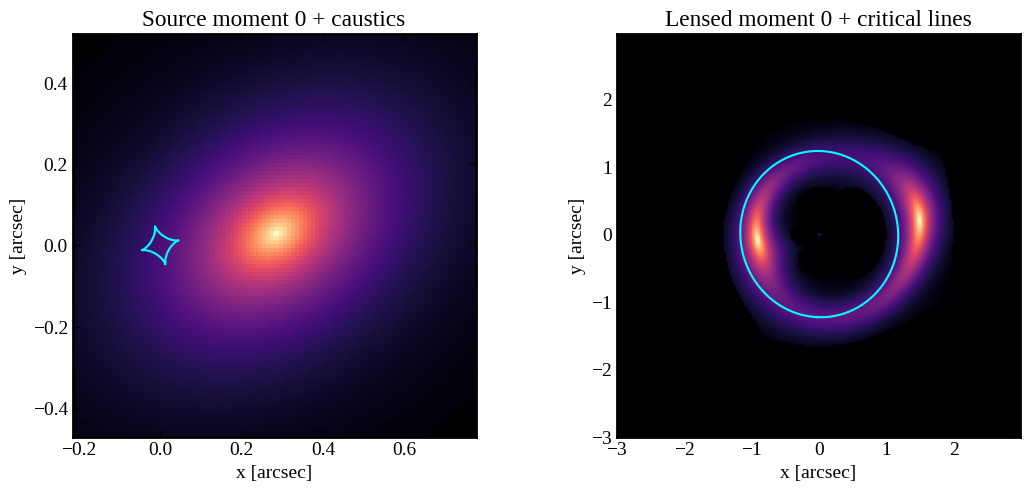

In [12]:
# 可視化には現在の設定で生成された先頭caseを使う。
reference_case = CASES[0]['name']
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), constrained_layout=True)

source_moment0 = INTRINSIC_CUBES[reference_case].sum(axis=0)
axes[0].imshow(
    source_moment0,
    origin='lower',
    cmap='magma',
    extent=(XX_SOURCE_ARCSEC.min(), XX_SOURCE_ARCSEC.max(),
            YY_SOURCE_ARCSEC.min(), YY_SOURCE_ARCSEC.max()),
)
for segment in LENS_GEOMETRY['caustics']:
    axes[0].plot(segment[:, 0], segment[:, 1], color='cyan', lw=1.5)
axes[0].set_title('Source moment 0 + caustics')

lensed_moment0 = LENSED_CUBES[reference_case].sum(axis=0)
axes[1].imshow(
    lensed_moment0,
    origin='lower',
    cmap='magma',
    extent=(XX_IMAGE_ARCSEC.min(), XX_IMAGE_ARCSEC.max(),
            YY_IMAGE_ARCSEC.min(), YY_IMAGE_ARCSEC.max()),
)
for segment in LENS_GEOMETRY['critical_lines']:
    axes[1].plot(segment[:, 0], segment[:, 1], color='cyan', lw=1.5)
axes[1].set_title('Lensed moment 0 + critical lines')

for ax in axes:
    ax.set_xlabel('x [arcsec]')
    ax.set_ylabel('y [arcsec]')
plt.show()

## Full noiseless channel maps

Moment maps can hide velocity-dependent mistakes, so every source- and image-plane channel is displayed for every mass case. A common color scale within each cube makes changes in line morphology and amplitude across velocity directly comparable.

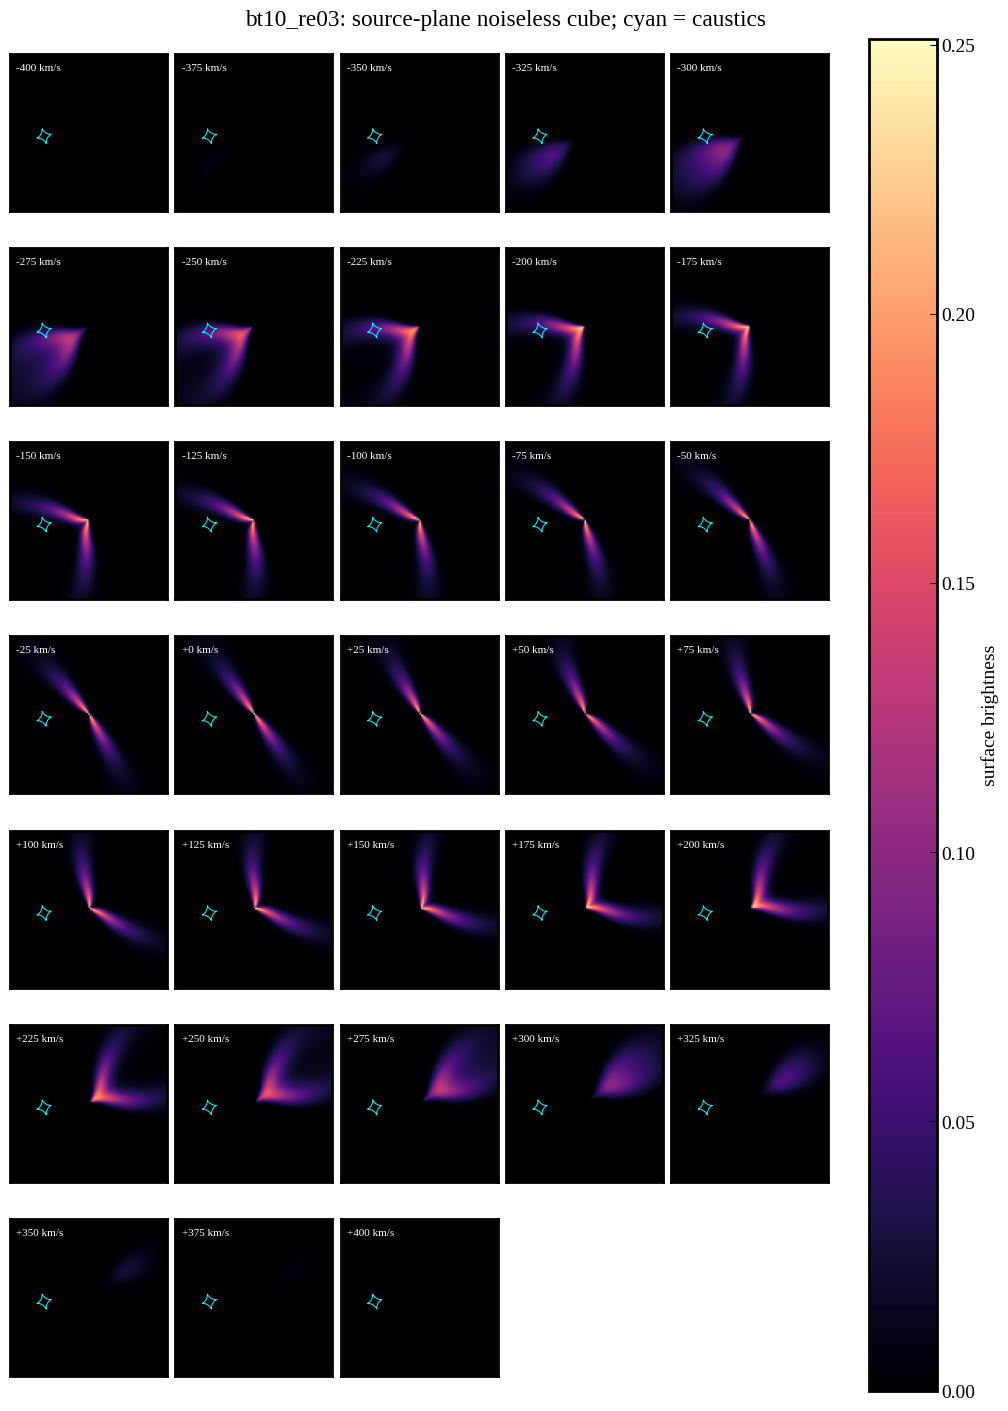

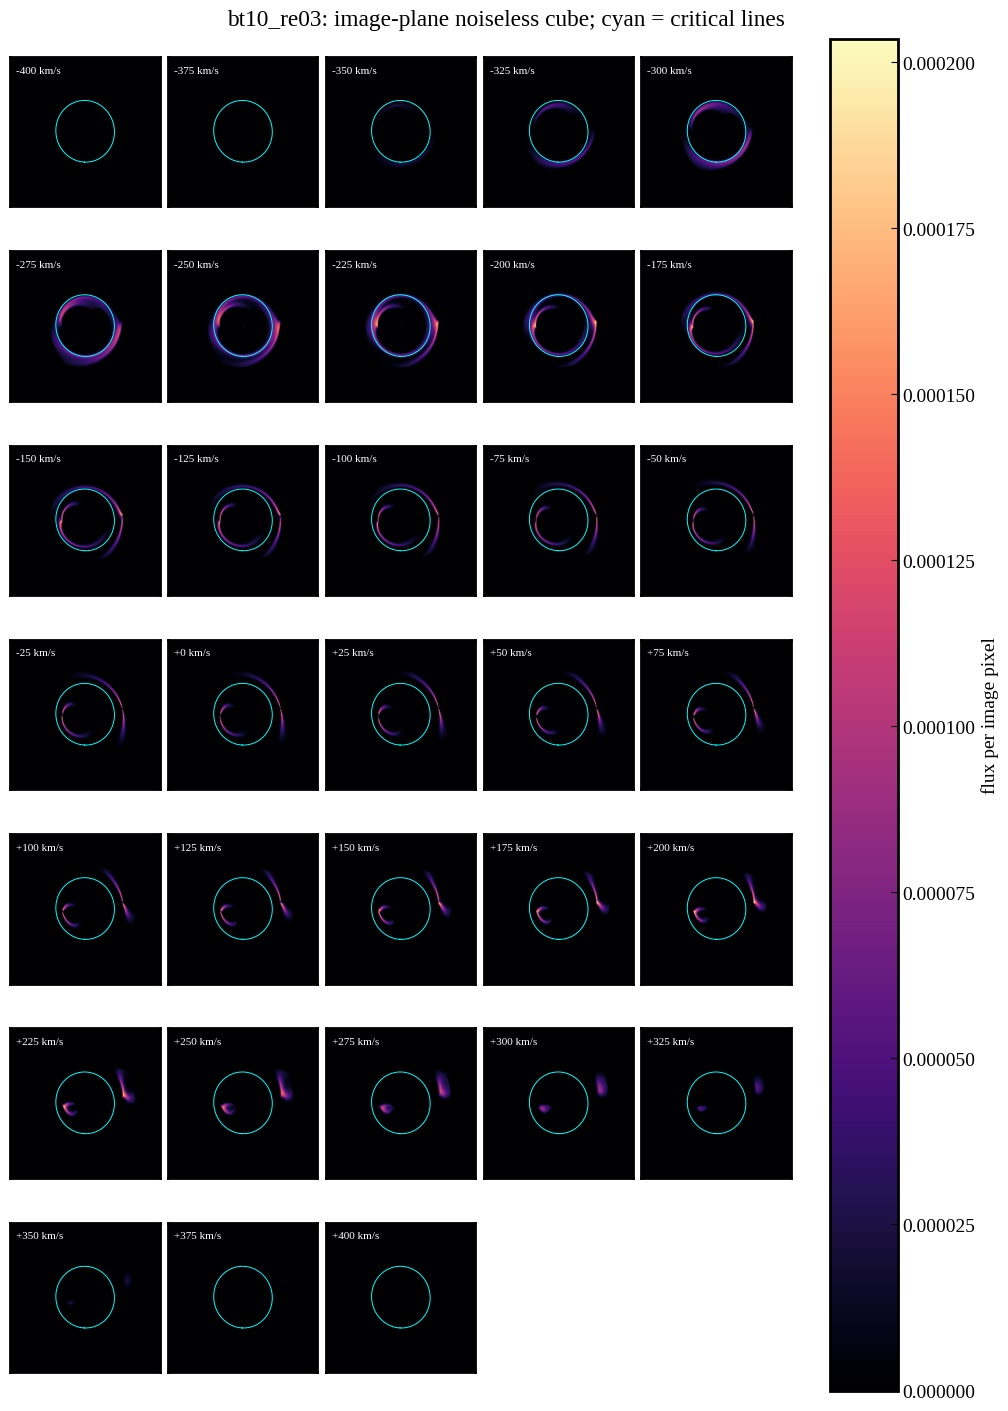

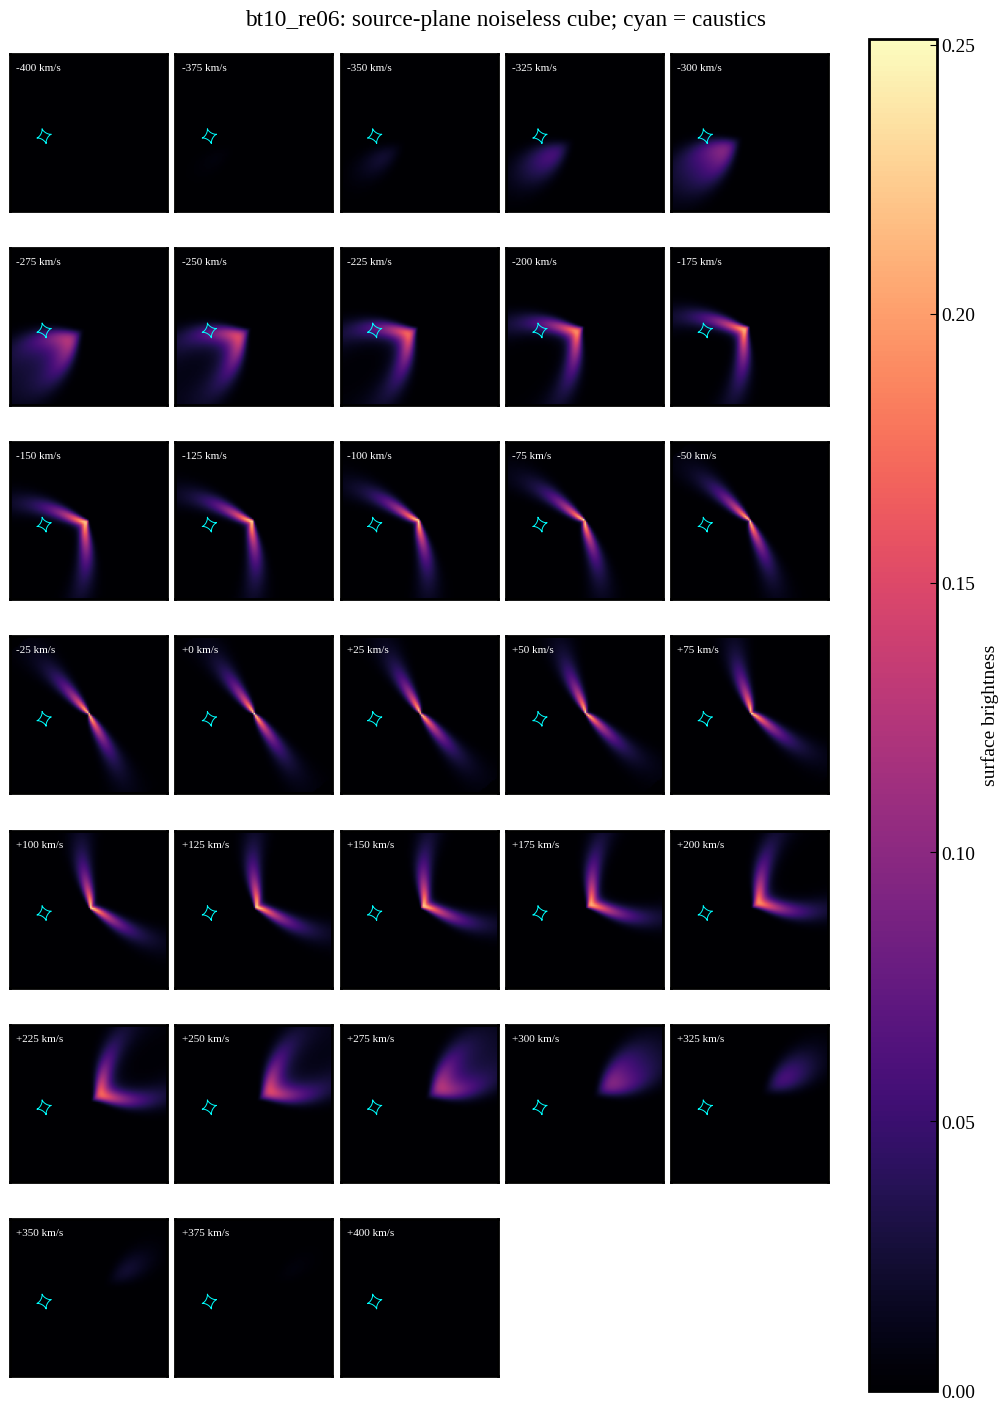

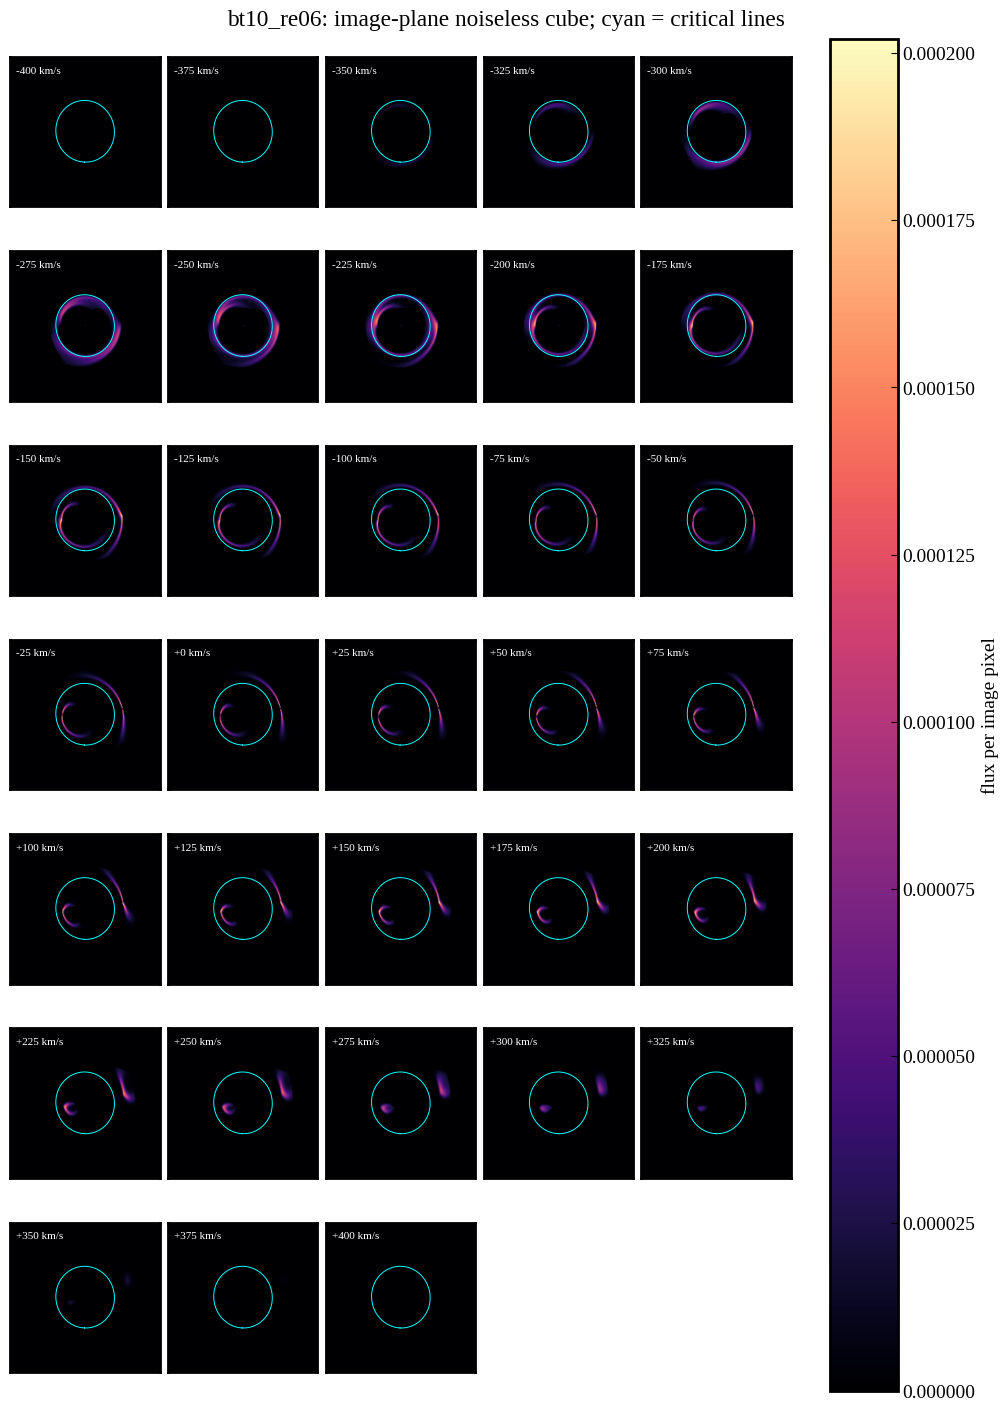

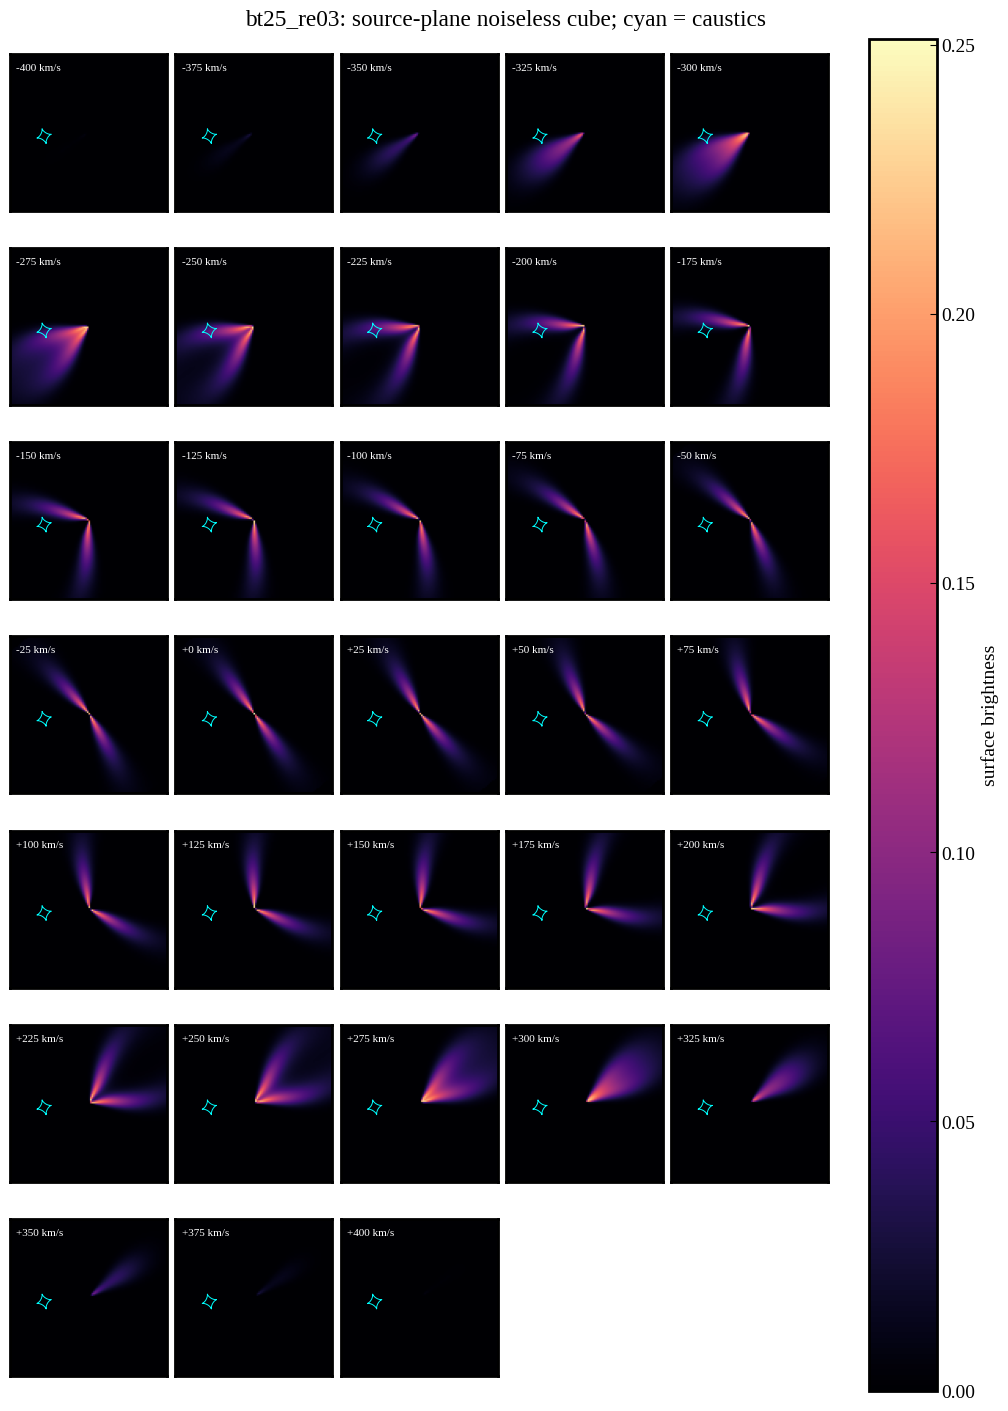

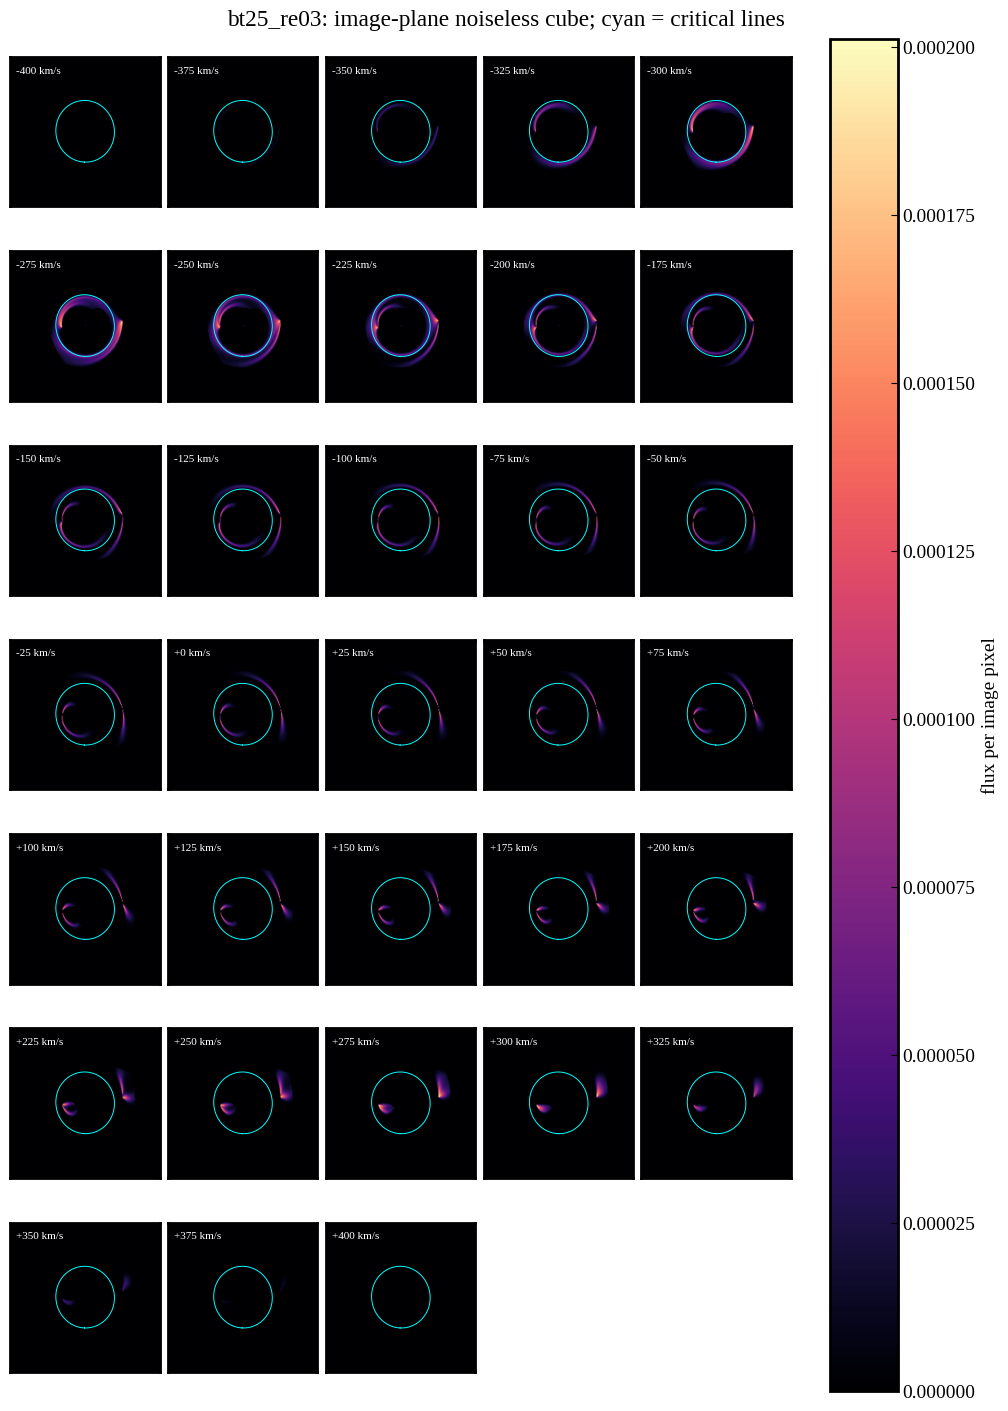

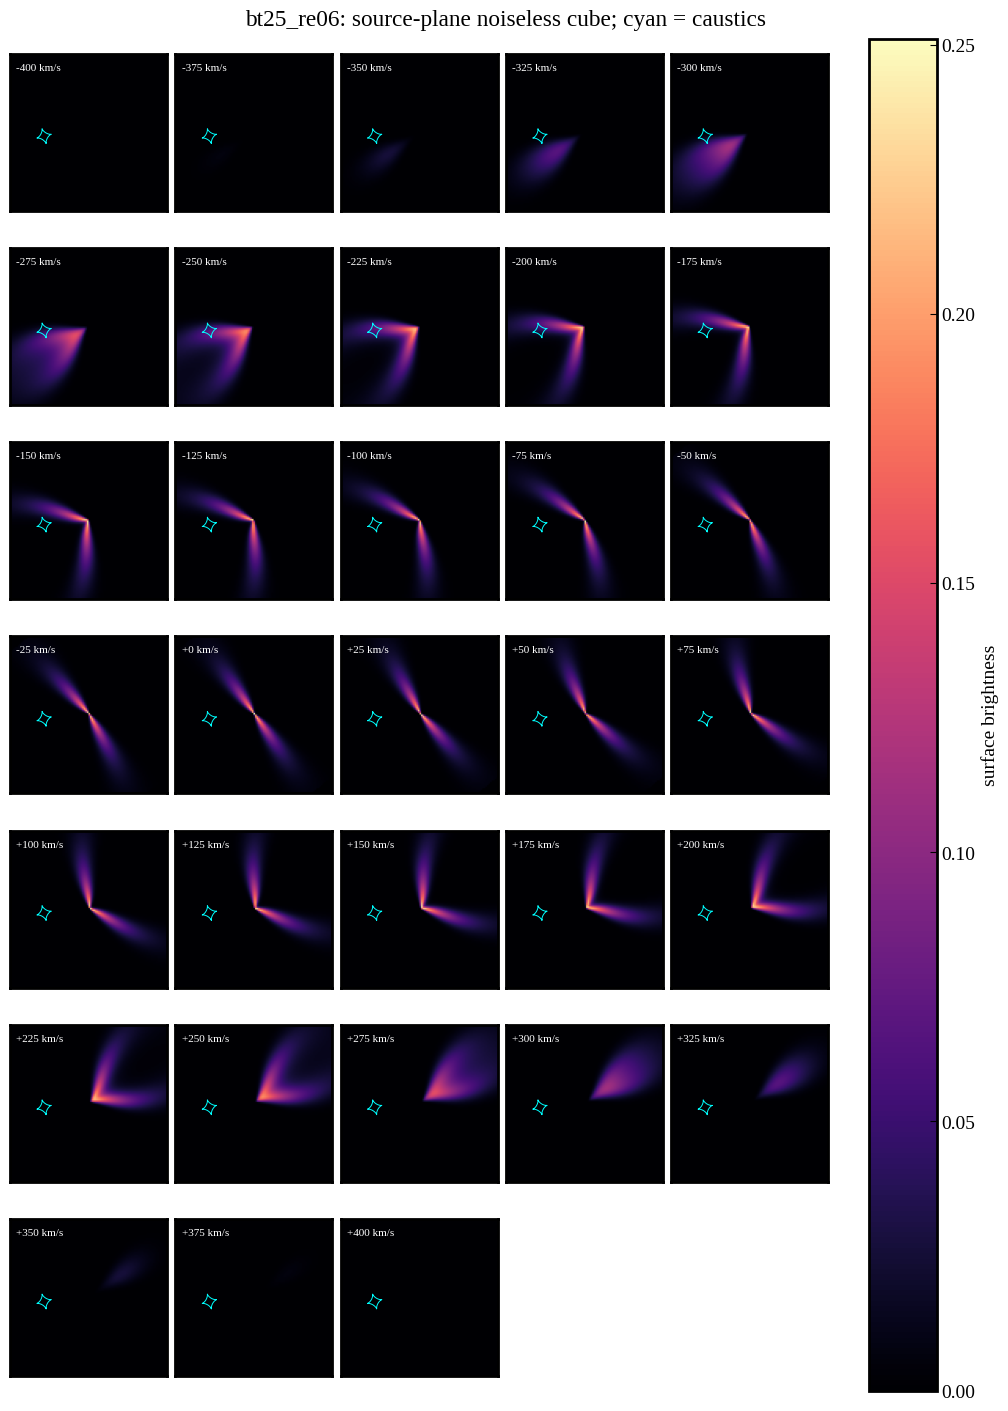

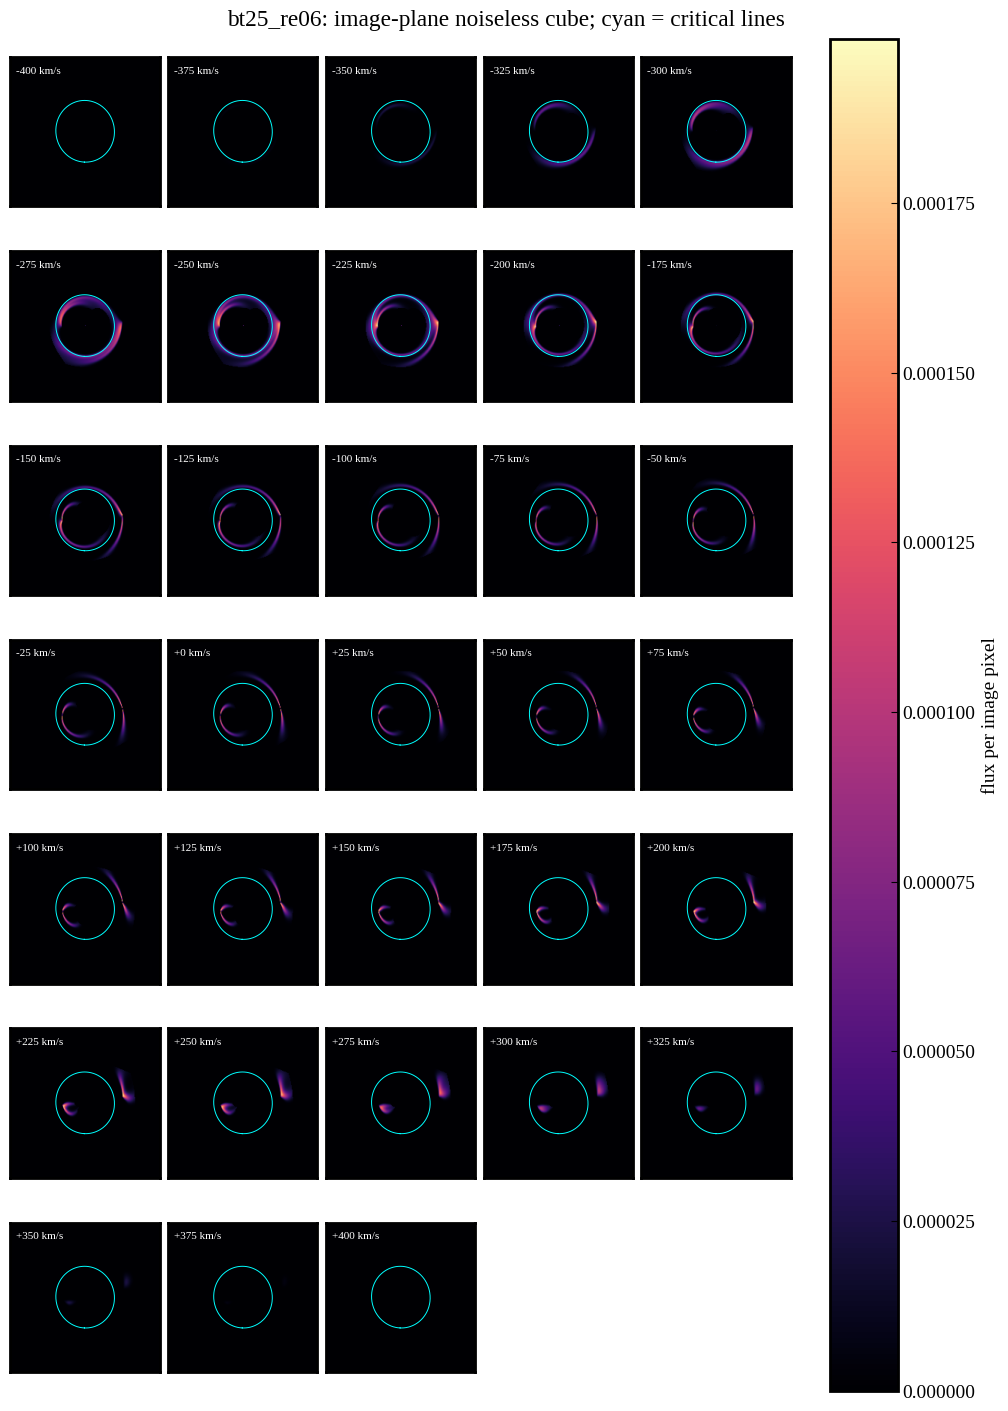

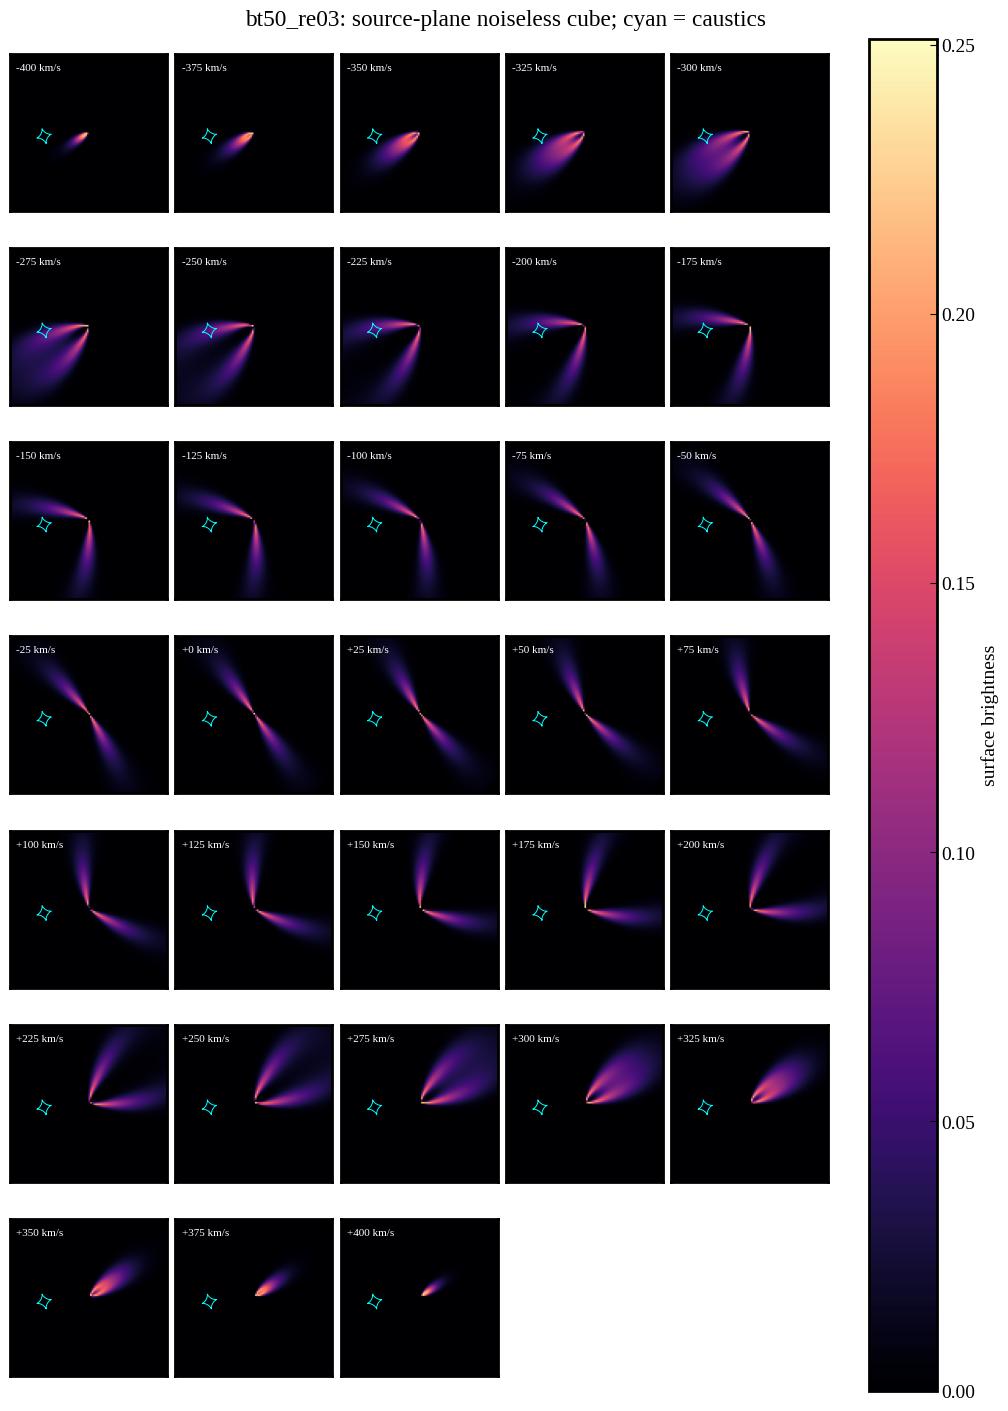

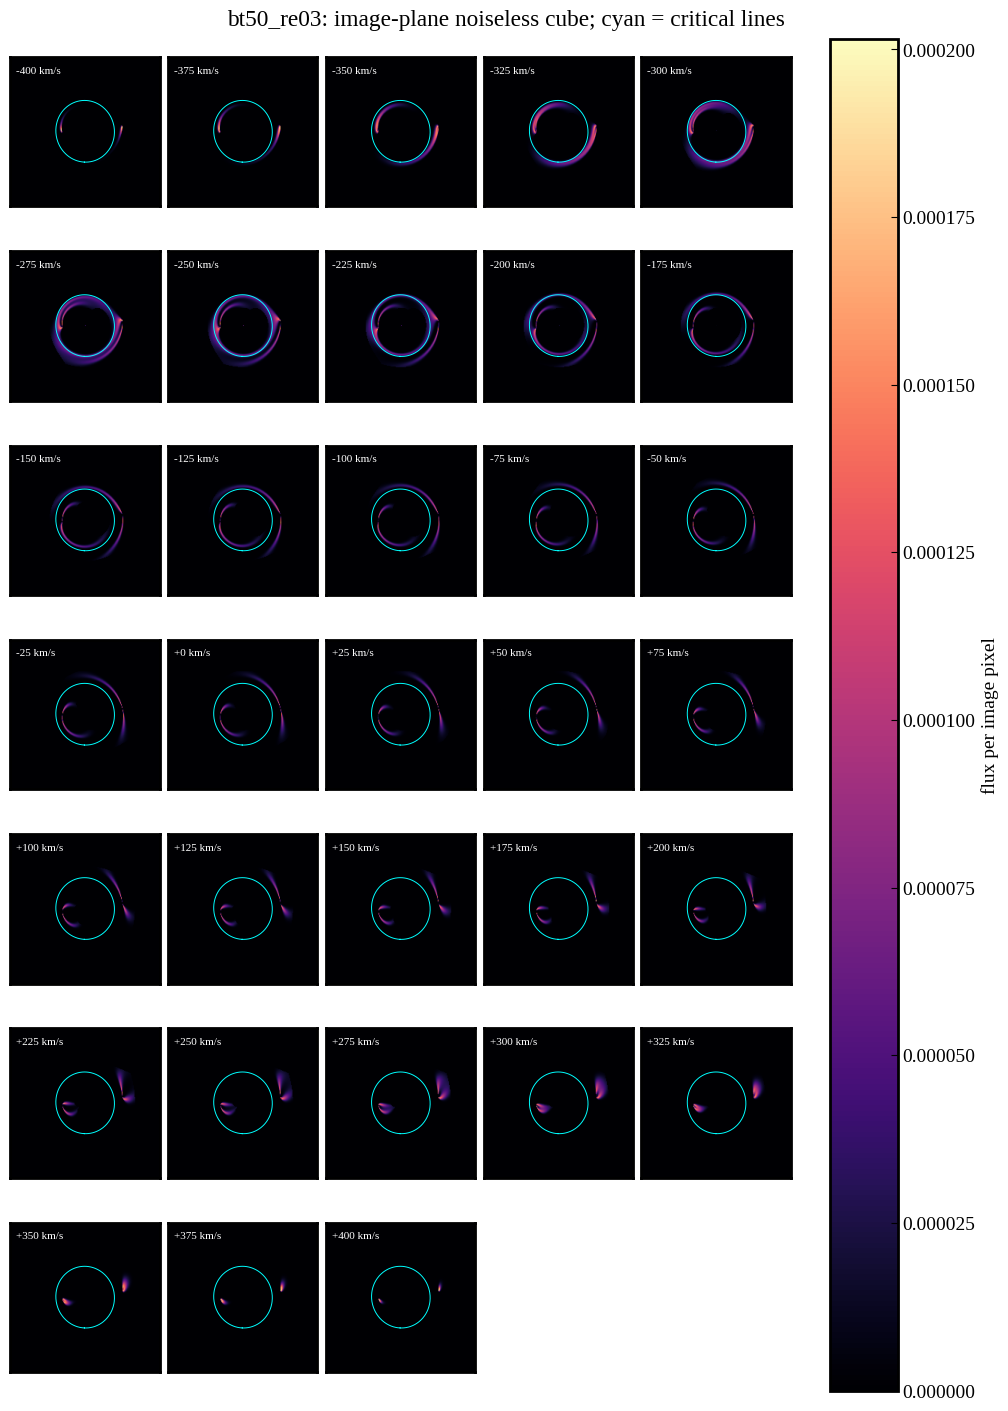

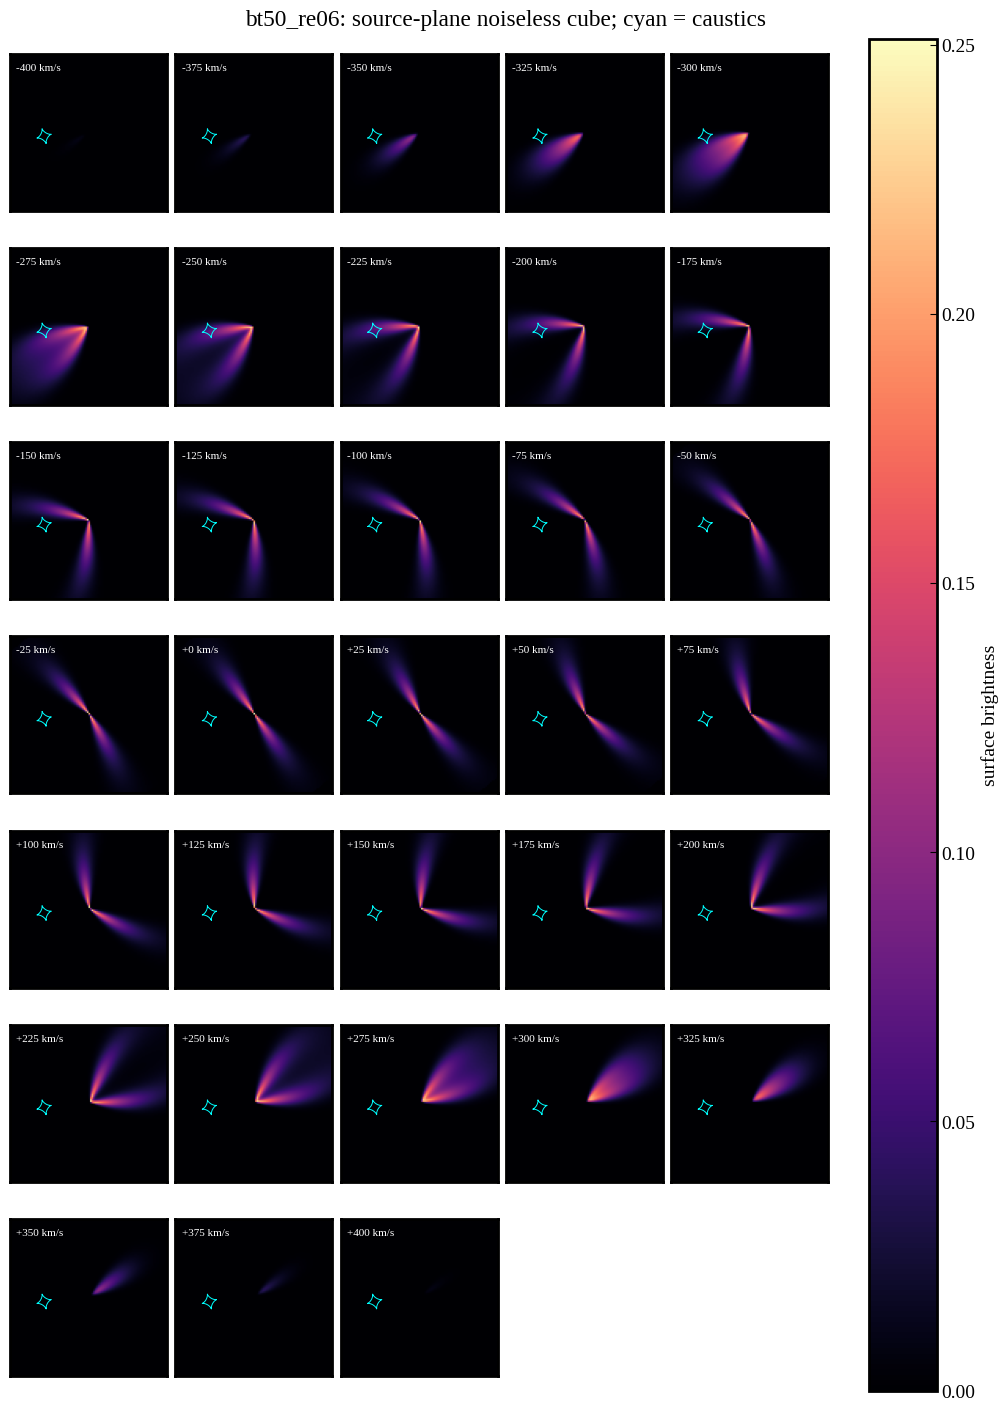

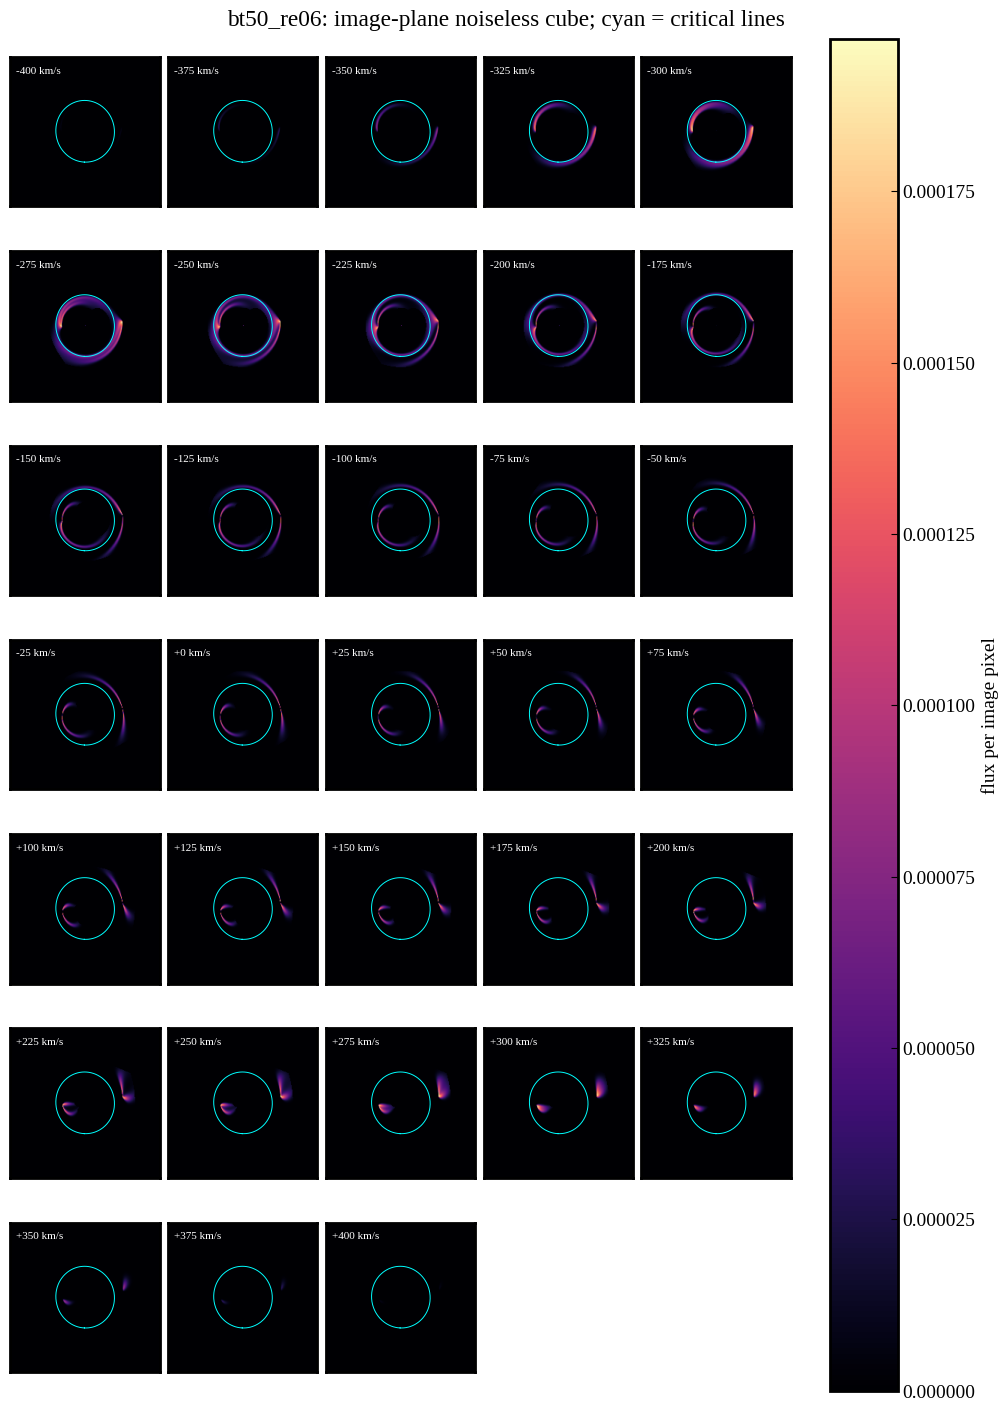

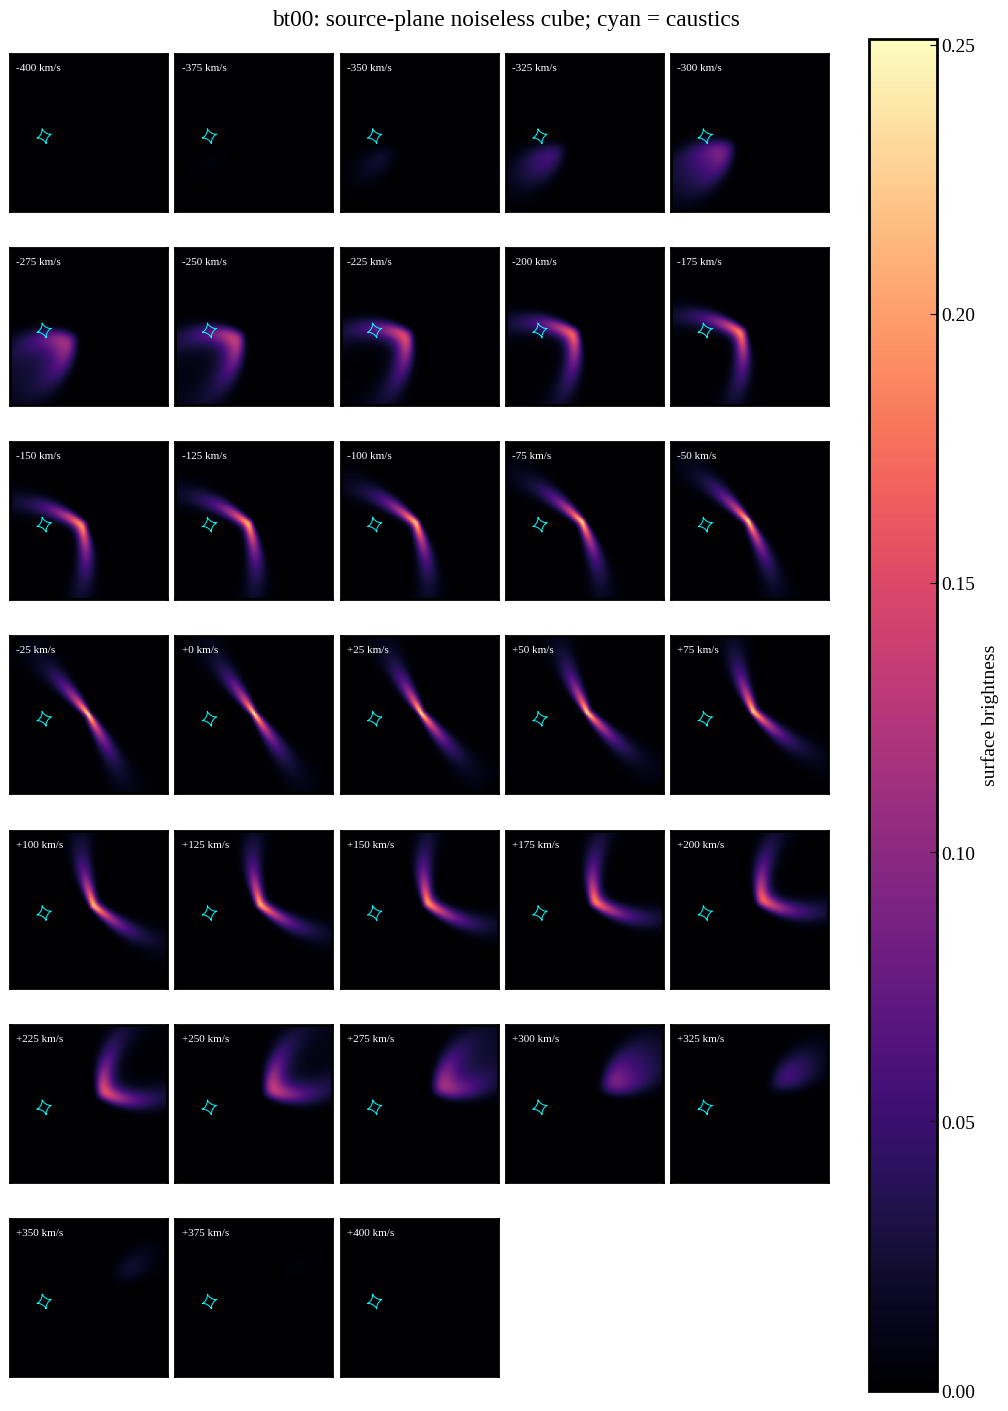

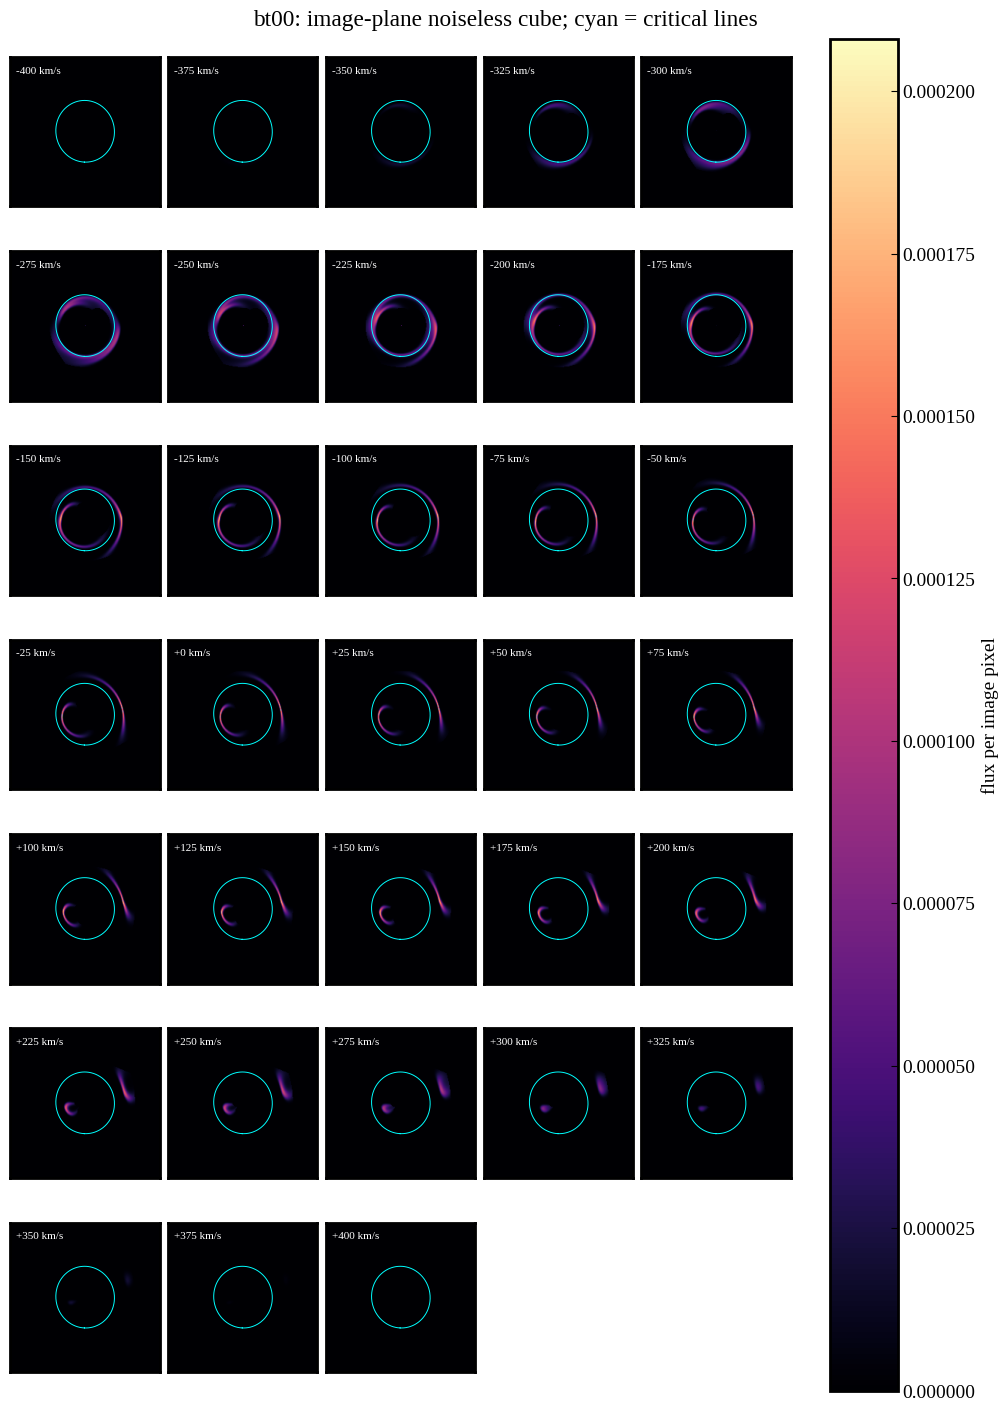

In [13]:
def plot_channel_maps(cube, xx, yy, case_name, plane, curves, curve_label, ncols=5):
    nchan = cube.shape[0]
    nrows = int(np.ceil(nchan / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(2 * ncols, 2 * nrows), constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()
    image = None
    vmax = float(np.nanmax(cube))
    extent = (xx.min(), xx.max(), yy.min(), yy.max())
    for channel, ax in enumerate(axes):
        if channel >= nchan:
            ax.set_visible(False)
            continue
        image = ax.imshow(cube[channel], origin='lower', cmap='magma', vmin=0.0, vmax=vmax, extent=extent)
        for segment in curves:
            ax.plot(segment[:, 0], segment[:, 1], color='cyan', lw=0.7)
        ax.text(
            0.04, 0.94, f'{VELOCITY_CHANNELS_KMS[channel]:+.0f} km/s',
            transform=ax.transAxes, ha='left', va='top', color='white', fontsize=8,
        )
        ax.set_xticks([])
        ax.set_yticks([])
    fig.colorbar(image, ax=axes[:nchan].tolist(), label='surface brightness' if plane == 'source' else 'flux per image pixel')
    fig.suptitle(f'{case_name}: {plane}-plane noiseless cube; cyan = {curve_label}')
    plt.show()

for case in CASES:
    name = case['name']
    plot_channel_maps(
        INTRINSIC_CUBES[name], XX_SOURCE_ARCSEC, YY_SOURCE_ARCSEC,
        name, 'source', LENS_GEOMETRY['caustics'], 'caustics',
    )
    plot_channel_maps(
        LENSED_CUBES[name], XX_IMAGE_ARCSEC, YY_IMAGE_ARCSEC,
        name, 'image', LENS_GEOMETRY['critical_lines'], 'critical lines',
    )

## Optional check: fixed-lens noiseless recovery

This is a numerical sanity check, not a realistic inference experiment. The noiseless image-plane cube is fitted with bounded least squares using the free parameters selected in `mock_stage1.toml`; every unlisted parameter remains fixed to truth.

This check can reveal inconsistencies between parameter unpacking, source generation, lens mapping, and residual construction. It does **not** demonstrate that the parameters will be identifiable with noise, a finite PSF, or realistic interferometric sampling—that is the purpose of later stages.

The objective is the flattened image-cube residual divided by the cube peak. Different cases are independent and are therefore fitted in parallel.

In [14]:
with (EXAMPLE_DIR / 'mock_stage1.toml').open('rb') as handle:
    RECOVERY_CONFIG = tomllib.load(handle)

FREE_PARAMETER_NAMES = tuple(RECOVERY_CONFIG['recovery']['free_parameters'])
unknown = set(FREE_PARAMETER_NAMES) - set(ALL_PARAMETER_NAMES)
if unknown:
    raise ValueError(f'Unsupported recovery parameters: {sorted(unknown)}')
if len(set(FREE_PARAMETER_NAMES)) != len(FREE_PARAMETER_NAMES):
    raise ValueError('free_parameters contains duplicates')

BOUNDS = RECOVERY_CONFIG['bounds']
LOWER_BOUNDS = np.array([BOUNDS[name]['lower'] for name in FREE_PARAMETER_NAMES])
UPPER_BOUNDS = np.array([BOUNDS[name]['upper'] for name in FREE_PARAMETER_NAMES])
INITIAL_GUESS = np.array([BOUNDS[name]['initial'] for name in FREE_PARAMETER_NAMES])

def free_vector(case):
    parameters = truth_parameters(case)
    return np.array([parameters[name] for name in FREE_PARAMETER_NAMES], dtype=float)

def complete_parameters(theta_free, case):
    parameters = truth_parameters(case)
    parameters.update(zip(FREE_PARAMETER_NAMES, np.asarray(theta_free, dtype=float), strict=True))
    return parameters

def recover_case(case):
    data_cube = LENSED_CUBES[case['name']]
    scale = float(np.max(data_cube))

    def residual(theta_free):
        # Rebuild the complete source and lensed cube for every optimizer step.
        parameters = complete_parameters(theta_free, case)
        source_model = intrinsic_cube(parameters)
        image_model = lensed_cube(source_model, parameters)
        return ((image_model - data_cube) / scale).ravel()


    fit = run_least_squares(
        residual, INITIAL_GUESS, LOWER_BOUNDS, UPPER_BOUNDS,
        ftol=1e-11, xtol=1e-11, gtol=1e-11, max_nfev=2000,
    )
    best_parameters = complete_parameters(fit.x, case)
    best_source_cube = intrinsic_cube(best_parameters)
    best_cube = lensed_cube(best_source_cube, best_parameters)
    # Singular values diagnose local degeneracies in the fitted parameter combination.
    singular_values = np.linalg.svd(fit.jac, compute_uv=False)
    return {
        'truth_free': free_vector(case),
        'best_free': fit.x,
        'best_parameters': best_parameters,
        'best_source_cube': best_source_cube,
        'best_cube': best_cube,
        'max_abs_cube_residual': float(np.max(np.abs(best_cube - data_cube))),
        'success': fit.success,
        'nfev': fit.nfev,
        'jacobian_singular_values': singular_values,
    }


MAX_WORKERS = int(RECOVERY_CONFIG['recovery']['max_workers'])
case_results = run_parallel_fits(recover_case, CASES, max_workers=MAX_WORKERS)
RESULTS = {case['name']: result for case, result in zip(CASES, case_results, strict=True)}
for case in CASES:
    result = RESULTS[case['name']]
    print(
        case['name'], 'success=', result['success'], 'nfev=', result['nfev'],
        'max |cube residual|=', f"{result['max_abs_cube_residual']:.3e}",
    )

bt10_re03 success= True nfev= 84 max |cube residual|= 9.459e-11
bt10_re06 success= True nfev= 103 max |cube residual|= 8.367e-11
bt25_re03 success= True nfev= 79 max |cube residual|= 8.004e-11
bt25_re06 success= True nfev= 86 max |cube residual|= 7.276e-11
bt50_re03 success= True nfev= 74 max |cube residual|= 6.185e-11
bt50_re06 success= True nfev= 76 max |cube residual|= 8.004e-11
bt00 success= True nfev= 114 max |cube residual|= 2.256e-10


In [15]:
rows = []
for case in CASES:
    best_parameters = RESULTS[case['name']]['best_parameters']
    truth = truth_parameters(case)
    for name in FREE_PARAMETER_NAMES:
        truth_value = truth[name]
        best = best_parameters[name]
        if name == 'bulge_effective_radius_kpc' and case['bulge_to_total'] == 0.0:
            truth_value, delta, relative_error = np.nan, np.nan, np.nan
        else:
            delta = best - truth_value
            relative_error = np.nan if truth_value == 0.0 else delta / truth_value
        rows.append((case['name'], name, truth_value, best, delta, relative_error))

RECOVERY_TABLE = Table(
    rows=rows,
    names=('case', 'parameter', 'truth', 'recovered', 'recovered - truth', 'relative error'),
)
for name in RECOVERY_TABLE.colnames[2:]:
    RECOVERY_TABLE[name].format = '.6g'
RECOVERY_TABLE.pprint_all()

   case              parameter             truth  recovered   recovered - truth relative error
--------- -------------------------------- ----- ------------ ----------------- --------------
bt10_re03                   log10_m_baryon    11           11       1.58757e-08    1.44325e-09
bt10_re03            disk_scale_radius_kpc     1            1       1.60191e-08    1.60191e-08
bt10_re03                   bulge_to_total   0.1          0.1       2.72179e-09    2.72179e-08
bt10_re03       bulge_effective_radius_kpc   0.3          0.3       1.29432e-08    4.31441e-08
bt10_re03                  source_x_arcsec 0.285        0.285       2.17183e-10    7.62046e-10
bt10_re03                  source_y_arcsec  0.03         0.03      -9.09518e-10   -3.03173e-08
bt10_re03               flux_normalization     1            1      -9.63885e-09   -9.63885e-09
bt10_re03                  inclination_deg    45           45      -3.88214e-07   -8.62698e-09
bt10_re03               position_angle_deg    35  

## Recovery diagnostics

Three complementary diagnostics are shown:

1. a table comparing truth and recovered values for every free parameter;
2. total and component rotation curves, which reveal compensating disk/bulge/halo solutions;
3. truth/model/residual image slices plus the reconstructed intrinsic source.

The Jacobian condition number is also reported. A very large value or very small minimum singular value means that some parameter combinations are locally poorly constrained even when the cube residual is nearly zero.

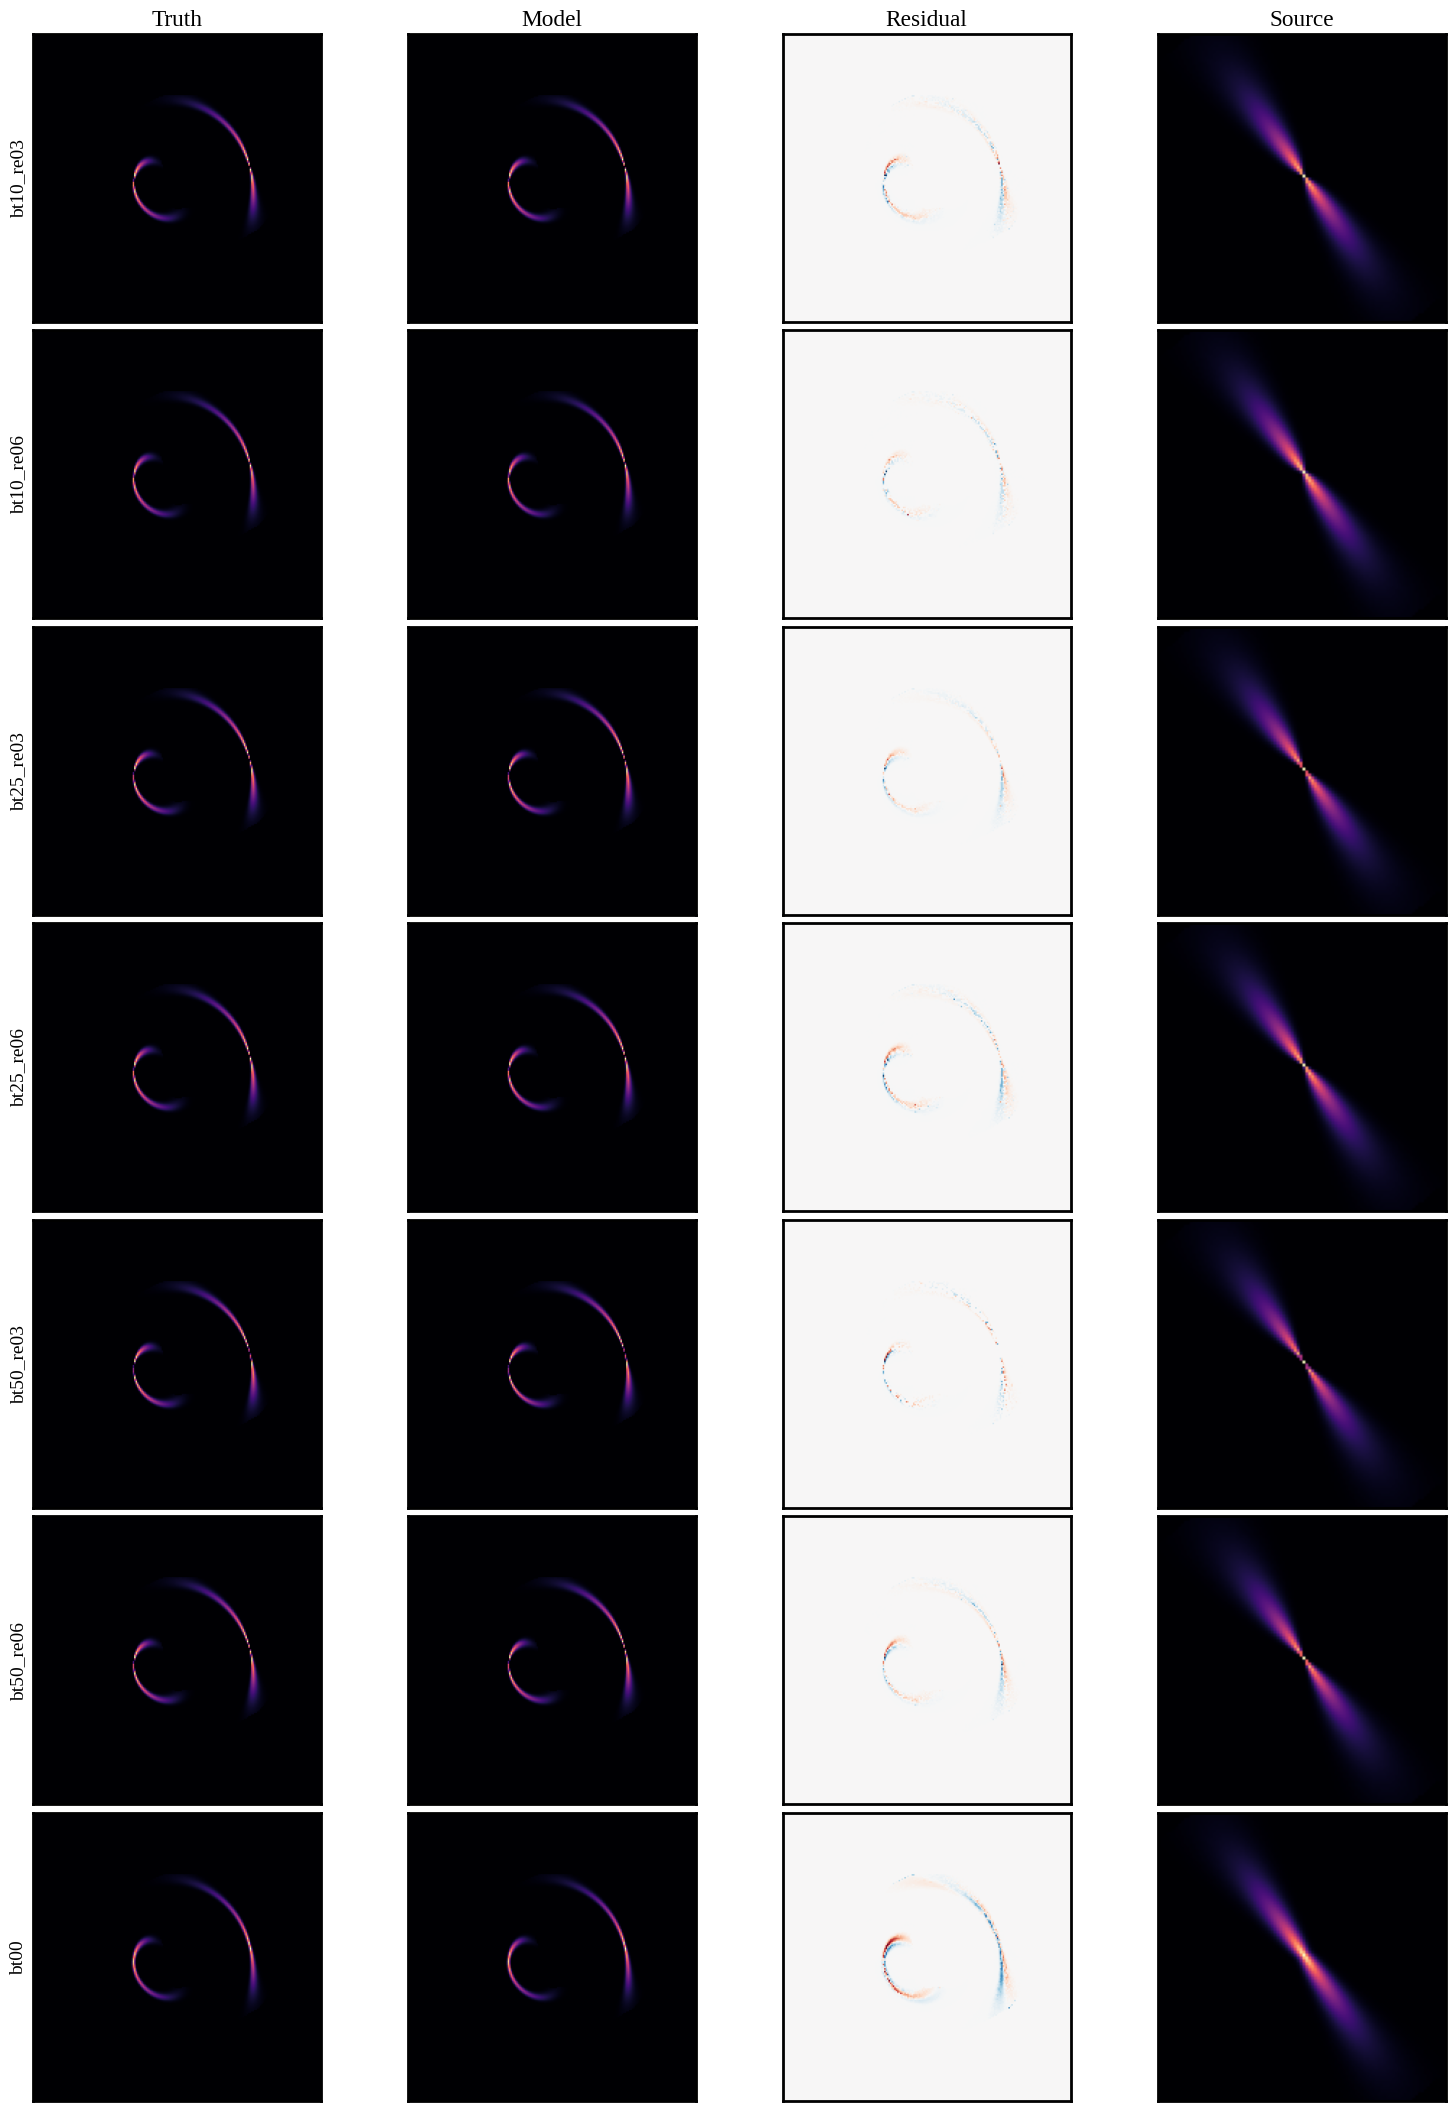

case,Jacobian condition number,smallest singular value
str9,float64,float64
bt10_re03,7480.704797411004,0.17336888279599108
bt10_re06,8310.76208415205,0.14849305884454483
bt25_re03,6775.620403404083,0.22277903410454436
bt25_re06,7739.585770181347,0.17836255957525374
bt50_re03,8997.824136904695,0.2087130278092335
bt50_re06,7122.684777440681,0.21854981190289452
bt00,1.0396757214136328e+17,1.0549554553579323e-14


In [16]:
fig, axes = plt.subplots(
    len(CASES), 4, figsize=(15, 3 * len(CASES)), constrained_layout=True, squeeze=False,
)
identifiability_rows = []
for row, case in enumerate(CASES):
    data_cube = LENSED_CUBES[case['name']]
    best_cube = RESULTS[case['name']]['best_cube']
    best_source_cube = RESULTS[case['name']]['best_source_cube']
    middle = VELOCITY_CHANNELS_KMS.size // 2
    image_extent = (
        XX_IMAGE_ARCSEC.min(), XX_IMAGE_ARCSEC.max(),
        YY_IMAGE_ARCSEC.min(), YY_IMAGE_ARCSEC.max(),
    )
    source_extent = (
        XX_SOURCE_ARCSEC.min(), XX_SOURCE_ARCSEC.max(),
        YY_SOURCE_ARCSEC.min(), YY_SOURCE_ARCSEC.max(),
    )
    vmax = float(np.max(data_cube[middle]))
    axes[row, 0].imshow(data_cube[middle], origin='lower', cmap='magma', vmin=0.0, vmax=vmax, extent=image_extent)
    axes[row, 1].imshow(best_cube[middle], origin='lower', cmap='magma', vmin=0.0, vmax=vmax, extent=image_extent)
    residual = best_cube[middle] - data_cube[middle]
    limit = max(float(np.max(np.abs(residual))), np.finfo(float).eps)
    axes[row, 2].imshow(residual, origin='lower', cmap='RdBu_r', vmin=-limit, vmax=limit, extent=image_extent)
    axes[row, 3].imshow(best_source_cube[middle], origin='lower', cmap='magma', extent=source_extent)
    axes[row, 0].set_ylabel(case['name'])
    if row == 0:
        for ax, title in zip(axes[row], ('Truth', 'Model', 'Residual', 'Source'), strict=True):
            ax.set_title(title)
    for ax in axes[row]:
        ax.set_xticks([])
        ax.set_yticks([])

    singular_values = RESULTS[case['name']]['jacobian_singular_values']
    condition = np.inf if singular_values[-1] == 0 else singular_values[0] / singular_values[-1]
    identifiability_rows.append((case['name'], condition, singular_values[-1]))
plt.show()

Table(
    rows=identifiability_rows,
    names=('case', 'Jacobian condition number', 'smallest singular value'),
)